<h1 style='color: black; background-color: #1fad72; padding: 18px; border-radius: 8px; text-align: center; font-family: Segoe UI, Arial; border: 1px solid #E3E8EE;'><B>
NYC Airbnb Market Analysis: Pricing Dynamics & Host Behavior</B>
</h1>



<div style= "color: black ;background-color: #1fad72; padding: 15px; border-radius:5px;text-align: left; font-family: Segoe UI, Arial;"> <strong>INTRODUCTION</strong> </div>

<h >This project analyzes the <b>NYC Airbnb dataset</b> to uncover key pricing patterns and host behaviors across New York City’s short-term rental market.

The analysis covers data cleaning, outlier treatment, and exploratory visualization to derive actionable insights on supply, demand, and pricing strategy.

<h>Airbnb has transformed urban hospitality by enabling Individuals and Commercial hosts to monetize spare capacity. New York City represents one of Airbnb’s largest and most regulated markets, with 5000+ active listings spanning 5 boroughs and 4 room types. However, NYC’s market dynamics often defy standard pricing logic seen in other cities due to high demand, Local Law 18 compliance rules, and spatial scarcity. The company was founded in 2008. Airbnb is a shortened version of its original name, AirBedandBreakfast.com.

**Problem Statement**  
For guests, choosing the right Airbnb in NYC is complex: prices range from $60 to $1198/night with minimal borough-based differentiation. For hosts, strategies around verification, minimum nights, and availability directly impact revenue. For regulators, ~37% Commercial hosts and short-term Entire home rentals create compliance risk under NYC laws.

**Objective of Study**  
This project uses the <b>“Airbnb Open Data” </b>dataset from Kaggle to perform Exploratory Data Analysis on 5000 NYC listings. The goals are to:
1. Identify pricing drivers: borough, room type, host verification, and availability
2. Compare Individual vs Commercial host strategies  
3. Flag regulatory risk using minimum night rules + license data
4. Provide actionable insights for guests, hosts, and the platform


**Approach**  
Python was used for data cleaning, statistical analysis, and visualization using pandas, numpy, matplotlib, and seaborn. Analysis focuses on descriptive stats, groupby comparisons, correlation analysis, and risk scoring to derive business insights.

This report is structured as: Data Cleaning → EDA → Insights → Recommendations → Conclusion.

<div style= "color: black ;background-color: #1fad72; padding: 15px; border-radius:5px;text-align: left; font-family: Segoe UI, Arial;"> <strong>DATA SOURCE</strong> </div>



<h>This analysis uses the **New York City Airbnb Open Data** dataset and covers Manhattan, Brooklyn, Queens, Bronx & Staten Island.

<b>Publisher</b>: Azmoudeh, A. (2023). *Airbnb Open Data*, Kaggle.  


<b>Access</b>: Publicly available on Kaggle [https://www.kaggle.com/datasets/arianazmoudeh/airbnbopendata] and contains ~102599 listings with 26 features.

<b>Disclaimer</b>: This is a third-party dataset and not officially endorsed by Airbnb. All analysis is for academic and portfolio purposes only.</h>

<div style= "color: black ;background-color: #1fad72; padding: 15px; border-radius:5px;text-align: left; font-family: Segoe UI, Arial;"> <strong>DATA ATTRIBUTES</strong> </div>

The dataset contains over 5000 NYC Airbnb listings with 26 columns. Key attributes grouped by theme:

##### **1. Listing Identity**
| Column | Type | Meaning |
| --- | --- | --- |
| `id` | int | Unique listing ID from Airbnb |
| `name` | object | Title of the Airbnb listing |
| `host_id` | int | Unique host ID |
| `host_name` | object | Name of host as shown on Airbnb |

##### **2. Location**
| Column | Type | Meaning |
| --- | --- | --- |
| `neighbourhood_group` | object | Borough: Manhattan, Brooklyn, Queens, Bronx, Staten Island |
| `neighbourhood` | object | Sub-area/neighborhood within borough, e.g. Williamsburg |
| `latitude`, `longitude` | float | GPS coordinates for mapping |
| `country`, `country_code` | object | Always "United States" / "US" for this NYC dataset |

##### **3. Property Details**
| Column | Type | Meaning |
| --- | --- | --- |
| `room_type` | object | 4 types: Entire home/apt, Private room, Shared room, Hotel room |
| `price` | float | Nightly price in USD. Needs cleaning to remove $ and commas |
| `service_fee` | float | Airbnb service fee charged to guest |
| `minimum_nights` | int | Minimum nights guest must book. NYC law makes <30 nights risky for Entire homes |
| `availability_365` | int | Number of days/year listing is available. 365 = always available |
| `construction_year` | float | Year of building construction |

##### **4. Host Details**
| Column | Type | Meaning |
| --- | --- | --- |
| `host_identity_verified` | object | Verified, Unconfirmed, Unknown. Airbnb ID check status |
| `calculated_host_listings_count` | int | Total listings this host has on Airbnb. Used to classify Individual vs Commercial host |
| `host_type` | derived | Individual if count=1, Commercial if count>1 |

##### **5. Reviews & Rating**
| Column | Type | Meaning |
| --- | --- | --- |
| `number_of_reviews` | int | Total reviews received till date |
| `last_review` | datetime | Date of most recent review |
| `reviews_per_month` | float | Avg reviews per month = demand proxy. Higher = more bookings |
| `review_rate_number` | float | Overall rating 1-5 given by guests |

##### **6. Compliance / Risk**
| Column | Type | Meaning |
| --- | --- | --- |
| `license` | object | NYC short-term rental license number. Null = potential Local Law 18 violation |
| `instant_bookable` | bool | True if guest can book without host approval |
| `cancellation_policy` | object | strict, moderate, flexible |

**Derived Features used in EDA:**  
1. `net_rate` = `price + service_fee` → True cost to guest  
2. `illegal_risk_score` = 1 if `room_type=Entire home/apt AND minimum_nights<30 AND license is null`  
3. `host_type` = Individual vs Commercial based on `calculated_host_listings_count`



<div style= "color: black ;background-color: #1fad72; padding: 15px; border-radius:5px;text-align:left; font-family: Segoe UI, Arial;"> <strong>IMPORTING PYTHON LIBRARIES</strong> </div>

<h>I would require python libraries like numpy,pandas, seaborn,matplotlib for detailes data exploration, cleaning, EDA and visulaization procedures to draw sales and marketing insights. So the first step towards this is importing these libraries, which is shown in the following cell.</h>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

<div style= "color: black ;background-color: #1fad72; padding: 15px; border-radius:5px;text-align: left; font-family: Segoe UI, Arial;"> <strong>DATA LOADING AND INITIAL OVERVIEW</strong> </div>

In this section, I loaded the csv file to python workbook and conducted a detailed analysis, to study the number of rows and columns, different attributes being listed, datatypes of each element, and identify missing values in the dataset.

<h> <B>Importing the dataset</B></h>
<body>The first step towards data exploration was to import the dataset to the ipynb file. To get a basic overview of the dataset, i used the info() function as follows.</body>

In [2]:
df= pd.read_csv("Airbnb_Open_Data.csv")
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 102599 entries, 0 to 102598
Data columns (total 26 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   id                              102599 non-null  int64  
 1   NAME                            102349 non-null  str    
 2   host id                         102599 non-null  int64  
 3   host_identity_verified          102310 non-null  str    
 4   host name                       102193 non-null  str    
 5   neighbourhood group             102570 non-null  str    
 6   neighbourhood                   102583 non-null  str    
 7   lat                             102591 non-null  float64
 8   long                            102591 non-null  float64
 9   country                         102067 non-null  str    
 10  country code                    102468 non-null  str    
 11  instant_bookable                102494 non-null  object 
 12  cancellation_policy        

C:\Users\Asian\AppData\Local\Temp\ipykernel_7132\3915407843.py:1: DtypeWarning: Columns (0: license) have mixed types. Specify dtype option on import or set low_memory=False.
  df= pd.read_csv("Airbnb_Open_Data.csv")


Once the file is imported, the next step is to understand the size, datatypes, attributes, check for null values or any anomalies. All these are done in the upcoming lines.

In [3]:
print("Number of Rows and Columns:",df.shape)

Number of Rows and Columns: (102599, 26)


In [4]:
print("Column Names:",df.columns)

Column Names: Index(['id', 'NAME', 'host id', 'host_identity_verified', 'host name',
       'neighbourhood group', 'neighbourhood', 'lat', 'long', 'country',
       'country code', 'instant_bookable', 'cancellation_policy', 'room type',
       'Construction year', 'price', 'service fee', 'minimum nights',
       'number of reviews', 'last review', 'reviews per month',
       'review rate number', 'calculated host listings count',
       'availability 365', 'house_rules', 'license'],
      dtype='str')


In [5]:
print("Datatypes of each column:  ",df.dtypes)

Datatypes of each column:   id                                  int64
NAME                                  str
host id                             int64
host_identity_verified                str
host name                             str
neighbourhood group                   str
neighbourhood                         str
lat                               float64
long                              float64
country                               str
country code                          str
instant_bookable                   object
cancellation_policy                   str
room type                             str
Construction year                 float64
price                                 str
service fee                           str
minimum nights                    float64
number of reviews                 float64
last review                           str
reviews per month                 float64
review rate number                float64
calculated host listings count    float64
availa

In [6]:
print("Quick Summary of the Dataset :" ,df.describe)

Quick Summary of the Dataset : <bound method NDFrame.describe of              id                                              NAME  \
0       1001254                Clean & quiet apt home by the park   
1       1002102                             Skylit Midtown Castle   
2       1002403               THE VILLAGE OF HARLEM....NEW YORK !   
3       1002755                                               NaN   
4       1003689  Entire Apt: Spacious Studio/Loft by central park   
...         ...                                               ...   
102594  6092437                        Spare room in Williamsburg   
102595  6092990                     Best Location near Columbia U   
102596  6093542                    Comfy, bright room in Brooklyn   
102597  6094094                  Big Studio-One Stop from Midtown   
102598  6094647                              585 sf Luxury Studio   

            host id host_identity_verified    host name neighbourhood group  \
0       80014485718        

In [7]:
print("Null Value Counts :   ",df.isnull().sum())

Null Value Counts :    id                                     0
NAME                                 250
host id                                0
host_identity_verified               289
host name                            406
neighbourhood group                   29
neighbourhood                         16
lat                                    8
long                                   8
country                              532
country code                         131
instant_bookable                     105
cancellation_policy                   76
room type                              0
Construction year                    214
price                                247
service fee                          273
minimum nights                       409
number of reviews                    183
last review                        15893
reviews per month                  15879
review rate number                   326
calculated host listings count       319
availability 365                  

<div style= "color: black ;background-color: #1fad72; padding: 15px; border-radius:5px;text-align: left; font-family: Segoe UI, Arial;"> <strong>DATA SCOPE</strong> </div>


For computational efficiency and robust visualization, this analysis uses a stratified random sample of 5,000 listings from the original 102599. 

**Stratification logic**: The sample maintains proportional representation across `neighbourhood_group` and `room_type` to preserve market structure. This approach ensures statistical validity while optimizing notebook performance for exploratory analysis.

**Result**: 5,000 rows × 16 columns, reflecting the full dataset’s borough distribution, room-type mix, and price dispersion.

In [8]:
df_new= df.sample(n=5000,random_state=42)

In [9]:
df_new.head(3)

,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
48202,27623301,NYC oasis in Gramercy,31250838867,unconfirmed,Michal,Manhattan,Stuyvesant Town,40.73549,-73.97707,United States,...,$190,20.0,0.0,NaN,NaN,4.0,1.0,30.0,NaN,NaN
94193,53024130,Gorgeous Times Square Flat!,46261863080,verified,Jowelle,Manhattan,Hell's Kitchen,40.76008,-73.98846,United States,...,$109,2.0,41.0,5/29/2019,2.79,5.0,5.0,169.0,NaN,NaN
90387,50922076,"Great Room &Host, steps from #1 train",17623893479,unconfirmed,Dee,Manhattan,Harlem,40.82378,-73.95354,United States,...,$162,60.0,13.0,8/15/2018,0.67,3.0,4.0,0.0,No smoking or parties please. Kaya (the fluffi...,NaN


<div style= "color: black ;background-color: #1fad72; padding: 15px; border-radius:5px;text-align: left; font-family: Segoe UI, Arial;"> <strong>DATA PROCESSING </strong> </div>

<div style= "color: black ;background-color: #1fad72; padding: 15px; border-radius:5px;text-align: left; font-family: Segoe UI, Arial;"> <strong>Identifying missing values and handling them  </strong> </div>

After extracting the required rows and columns, I removed all empty rows. In my dataset, there were no empty sets seen in the selected 5000rows.

In [10]:
newdf=df_new.dropna(how="all")
print(f"Removed {len(df_new)-len(newdf)}completely empty rows")

Removed 0completely empty rows


The next step was removing any irrelevant or unnecessary columns. In my file, the license column was sen to conatin too many missing values, but our analysis wouldn't need much of the details related to license.

In [11]:
df_new= df_new.drop(columns= "license")

The following lines represent shape, column names and statistical analysis of the truncated dataset consisting of 5000 rows and 25 columns.

In [12]:
df_new.shape

(5000, 25)

In [13]:
df_new.columns

Index(['id', 'NAME', 'host id', 'host_identity_verified', 'host name',
       'neighbourhood group', 'neighbourhood', 'lat', 'long', 'country',
       'country code', 'instant_bookable', 'cancellation_policy', 'room type',
       'Construction year', 'price', 'service fee', 'minimum nights',
       'number of reviews', 'last review', 'reviews per month',
       'review rate number', 'calculated host listings count',
       'availability 365', 'house_rules'],
      dtype='str')

In [14]:
df_new.dtypes

id                                  int64
NAME                                  str
host id                             int64
host_identity_verified                str
host name                             str
neighbourhood group                   str
neighbourhood                         str
lat                               float64
long                              float64
country                               str
country code                          str
instant_bookable                   object
cancellation_policy                   str
room type                             str
Construction year                 float64
price                                 str
service fee                           str
minimum nights                    float64
number of reviews                 float64
last review                           str
reviews per month                 float64
review rate number                float64
calculated host listings count    float64
availability 365                  

In [15]:
df_new.info

<bound method DataFrame.info of              id                                               NAME  \
48202  27623301                              NYC oasis in Gramercy   
94193  53024130                        Gorgeous Times Square Flat!   
90387  50922076              Great Room &Host, steps from #1 train   
89198  50265391        Spacious Private Bedroom in the North Bronx   
8266    5566648                 Colorful & Spacious near A Express   
...         ...                                                ...   
90255  50849173  Sunny, spacious Brooklyn getaway, with skylights!   
89534  50450964  Sleeps 6! 2 beds/2 ba Manhattan  1300 sq feet ...   
22367  13354630      Beautiful, Sunny, Artsy apartment in Brooklyn   
19663  11861211    Quiet Private Bedroom with Full Size Bed in LES   
98168  55219522  The Elkins House – Truly Rare, Historic 5BR 3 ...   

           host id host_identity_verified host name neighbourhood group  \
48202  31250838867            unconfirmed    Michal 

In [16]:
df_new.describe

<bound method NDFrame.describe of              id                                               NAME  \
48202  27623301                              NYC oasis in Gramercy   
94193  53024130                        Gorgeous Times Square Flat!   
90387  50922076              Great Room &Host, steps from #1 train   
89198  50265391        Spacious Private Bedroom in the North Bronx   
8266    5566648                 Colorful & Spacious near A Express   
...         ...                                                ...   
90255  50849173  Sunny, spacious Brooklyn getaway, with skylights!   
89534  50450964  Sleeps 6! 2 beds/2 ba Manhattan  1300 sq feet ...   
22367  13354630      Beautiful, Sunny, Artsy apartment in Brooklyn   
19663  11861211    Quiet Private Bedroom with Full Size Bed in LES   
98168  55219522  The Elkins House – Truly Rare, Historic 5BR 3 ...   

           host id host_identity_verified host name neighbourhood group  \
48202  31250838867            unconfirmed    Micha

In [17]:
df_new["host_identity_verified"].str.title()

48202    Unconfirmed
94193       Verified
90387    Unconfirmed
89198       Verified
8266        Verified
            ...     
90255    Unconfirmed
89534       Verified
22367    Unconfirmed
19663       Verified
98168    Unconfirmed
Name: host_identity_verified, Length: 5000, dtype: str

In [18]:
df_new.isnull().sum()

id                                   0
NAME                                 9
host id                              0
host_identity_verified               7
host name                           22
neighbourhood group                  0
neighbourhood                        1
lat                                  0
long                                 0
country                             26
country code                         2
instant_bookable                     2
cancellation_policy                  2
room type                            0
Construction year                   15
price                                8
service fee                         16
minimum nights                      17
number of reviews                    8
last review                        755
reviews per month                  755
review rate number                  20
calculated host listings count      21
availability 365                    24
house_rules                       2537
dtype: int64

I have replaced "Unknown" for the missing values in host_identity_verified and Name columns as I cannot fill them up with some assumed or calculated values

In [19]:
df_new["host_identity_verified"] =df_new["host_identity_verified"].fillna("Unknown")
df_new["NAME"]=df_new["NAME"].fillna("Unknown")

Converting datatypes of price and service fee columns to numeric for further computation.

In [20]:
for col in ['price']:
    df_new[col]=df_new[col].astype(str).str.replace("[$,]"," ", regex=True)
    df_new[col]=pd.to_numeric(df_new[col],errors='coerce')


In [21]:
for col in ["service fee"]:
    df_new[col]=df_new[col].astype(str).str.replace("[$,]"," ", regex=True)
    df_new[col] = pd.to_numeric(df_new[col], errors='coerce')

Filling missing values in remaining columns. I have used mean(), mode(),"Not Specified" or "Unknown" as per the context.

In [22]:
df_new["host name"] = df_new["host name"].fillna("Unknown")
df_new["neighbourhood"] = df_new["neighbourhood"].ffill()
df_new["country"] = df_new["country"].fillna("United States")
df_new["country code"] = df_new["country code"].fillna("US")
df_new["instant_bookable"] = df_new["instant_bookable"].fillna(df_new["instant_bookable"].mode()[0])
df_new["cancellation_policy"] = df_new["cancellation_policy"].fillna("Unknown")
df_new["Construction year"] = df_new["Construction year"].fillna(df_new["Construction year"].median())
df_new["price"] = df_new["price"].fillna(df_new["price"].mean())
df_new["service fee"] = df_new["service fee"].fillna(df_new["service fee"].mean())
df_new["minimum nights"] = df_new["minimum nights"].fillna(df_new["minimum nights"].mean())
df_new["number of reviews"]= df_new["number of reviews"].fillna(df_new["number of reviews"].mean())
df_new["last review"] = df_new["last review"].fillna("Unknown")
df_new["reviews per month"] = df_new["reviews per month"].fillna("Unknown")
df_new["review rate number"] = df_new["review rate number"].fillna(df_new["review rate number"].mode()[0])
df_new["calculated host listings count"] = df_new["calculated host listings count"].fillna(df_new["calculated host listings count"].mode()[0])
df_new["availability 365"] = df_new["availability 365"].fillna("Unknown")
df_new["house_rules"] = df_new["house_rules"].fillna("Not Specified")




<div style="
    border-left: 6px solid #27ae60;
    background-color: #f3fcf7;
    padding: 16px 18px;
    margin-top: 20px;
    font-size: 15px;
    color: #2c3e50;
    border-radius: 4px;
">
<strong>✔ Data exploration and cleaning successfully completed </strong><br><br>

</div>


In [23]:
df_new.isnull().sum()

id                                0
NAME                              0
host id                           0
host_identity_verified            0
host name                         0
neighbourhood group               0
neighbourhood                     0
lat                               0
long                              0
country                           0
country code                      0
instant_bookable                  0
cancellation_policy               0
room type                         0
Construction year                 0
price                             0
service fee                       0
minimum nights                    0
number of reviews                 0
last review                       0
reviews per month                 0
review rate number                0
calculated host listings count    0
availability 365                  0
house_rules                       0
dtype: int64

<div style= "color: black ;background-color: #1fad72; padding: 15px; border-radius:5px;text-align: left; font-family: Segoe UI, Arial;"> <strong> Standardizing & Formatting the data


 </strong> </div>

 I converted all the column names to uppercase letters.

In [24]:
df_new.columns =  df_new.columns.str.upper()
print(df_new.columns)

Index(['ID', 'NAME', 'HOST ID', 'HOST_IDENTITY_VERIFIED', 'HOST NAME',
       'NEIGHBOURHOOD GROUP', 'NEIGHBOURHOOD', 'LAT', 'LONG', 'COUNTRY',
       'COUNTRY CODE', 'INSTANT_BOOKABLE', 'CANCELLATION_POLICY', 'ROOM TYPE',
       'CONSTRUCTION YEAR', 'PRICE', 'SERVICE FEE', 'MINIMUM NIGHTS',
       'NUMBER OF REVIEWS', 'LAST REVIEW', 'REVIEWS PER MONTH',
       'REVIEW RATE NUMBER', 'CALCULATED HOST LISTINGS COUNT',
       'AVAILABILITY 365', 'HOUSE_RULES'],
      dtype='str')


I converted all cell elements to proper case

In [25]:
df_new["NAME"].str.title()
df_new["HOST NAME"].str.title()
df_new["CANCELLATION_POLICY"].str.title()
df_new["COUNTRY"].str.title()
df_new["COUNTRY CODE"].str.upper()
df_new["ROOM TYPE"].str.title()
df_new["HOUSE_RULES"].str.title()
df_new["LAST REVIEW"].str.title()
df_new["NEIGHBOURHOOD"].str.title()
df_new["NEIGHBOURHOOD GROUP"].str.title()


df_new.head(5)

,ID,NAME,HOST ID,HOST_IDENTITY_VERIFIED,HOST NAME,NEIGHBOURHOOD GROUP,NEIGHBOURHOOD,LAT,LONG,COUNTRY,...,PRICE,SERVICE FEE,MINIMUM NIGHTS,NUMBER OF REVIEWS,LAST REVIEW,REVIEWS PER MONTH,REVIEW RATE NUMBER,CALCULATED HOST LISTINGS COUNT,AVAILABILITY 365,HOUSE_RULES
48202,27623301,NYC oasis in Gramercy,31250838867,unconfirmed,Michal,Manhattan,Stuyvesant Town,40.73549,-73.97707,United States,...,951.0,190.0,20.0,0.0,Unknown,Unknown,4.0,1.0,30.0,Not Specified
94193,53024130,Gorgeous Times Square Flat!,46261863080,verified,Jowelle,Manhattan,Hell's Kitchen,40.76008,-73.98846,United States,...,543.0,109.0,2.0,41.0,5/29/2019,2.79,5.0,5.0,169.0,Not Specified
90387,50922076,"Great Room &Host, steps from #1 train",17623893479,unconfirmed,Dee,Manhattan,Harlem,40.82378,-73.95354,United States,...,812.0,162.0,60.0,13.0,8/15/2018,0.67,3.0,4.0,0.0,No smoking or parties please. Kaya (the fluffi...
89198,50265391,Spacious Private Bedroom in the North Bronx,48334233422,verified,Liliana,Bronx,Kingsbridge,40.88283,-73.89326,United States,...,328.0,66.0,3.0,2.0,5/25/2017,0.07,5.0,1.0,363.0,No smoking! If I smell smoke or if there is ot...
8266,5566648,Colorful & Spacious near A Express,45624334759,verified,Andrew,Manhattan,Washington Heights,40.85111,-73.93325,United States,...,132.0,26.0,2.0,48.0,6/30/2019,0.97,4.0,1.0,223.0,House Rules 1. Check-in is 4 pm local time. If...


In [26]:
df_new["HOST_IDENTITY_VERIFIED"].str.title()

48202    Unconfirmed
94193       Verified
90387    Unconfirmed
89198       Verified
8266        Verified
            ...     
90255    Unconfirmed
89534       Verified
22367    Unconfirmed
19663       Verified
98168    Unconfirmed
Name: HOST_IDENTITY_VERIFIED, Length: 5000, dtype: str

 I wanted to create a new column named NET RATE that showed the sum of price and service fee for each room. But before I write the code for the operation, I needed to identify and replace or fill in any null values and convert the datatypes of both columns to integer. Firstly, I found out that there are 8 null values in price column, and I used the mean() imputation to fill the null values. I filled up the 16 null values in service fee column using the same process. Once the nulls were filled in, I converted the datatypes to integer to make it uniform and add up the values.

In [27]:
df_new["NET RATE"]=df_new["PRICE"]+ df_new["SERVICE FEE"]
print(df_new[["PRICE","SERVICE FEE","NET RATE"]].head())

       PRICE  SERVICE FEE  NET RATE
48202  951.0        190.0    1141.0
94193  543.0        109.0     652.0
90387  812.0        162.0     974.0
89198  328.0         66.0     394.0
8266   132.0         26.0     158.0



<div style= "color: black ;background-color: #1fad72; padding: 15px; border-radius:5px;text-align: left ; font-family: Segoe UI, Arial;"> <strong>EXPLORATORY DATA ANALYSIS AND VISUALIZATION</strong> </div>


<div style= "color: black ;background-color: #1fad72; padding: 15px; border-radius:5px;text-align: left ; font-family: Segoe UI, Arial;"> <strong>Finding Outliers</strong> </div>


#### Calculate IQR bounds
 

In [28]:
col = 'MINIMUM NIGHTS'
print(df_new[col].describe())

count    5000.000000
mean        7.684527
std        19.140107
min         1.000000
25%         2.000000
50%         3.000000
75%         5.000000
max       366.000000
Name: MINIMUM NIGHTS, dtype: float64


In [29]:

Q1 = df_new[col].quantile(0.25)
Q3 = df_new[col].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"\nIQR bounds: {lower_bound:.2f} to {upper_bound:.2f}")



IQR bounds: -2.50 to 9.50


#### Identifying Outliers

In [30]:
outliers = df_new[(df_new[col] < lower_bound) | (df_new[col] > upper_bound)]
print(f"\nNumber of outliers: {len(outliers)}")
print(f"% of data: {len(outliers)/len(df_new)*100:.2f}%")


Number of outliers: 827
% of data: 16.54%


#### List of Top Outliers

In [31]:
outliers[[col, 'NAME', 'NEIGHBOURHOOD GROUP', 'PRICE']].sort_values(col, ascending=False).head(10)

,MINIMUM NIGHTS,NAME,NEIGHBOURHOOD GROUP,PRICE
186,366.0,SAFE AND BEAUTIFUL ACCOMODATION,Brooklyn,946.000000
64569,365.0,Stylish Upper East Side Studio Apartment,Manhattan,738.000000
44430,365.0,Room with sofa bed or air mattress,Queens,521.655639
3946,365.0,Close to everything - Jr 1 bedroom,Manhattan,140.000000
66278,365.0,Nice and safe ROOM near LGA/Manhattan,Queens,712.000000
99882,365.0,"Stunning 1 Br, West Village Luxury w/ great views",Manhattan,740.000000
31731,365.0,Long term/16 month sublet. Great location!,Brooklyn,557.000000
21709,300.0,Small Cozy Room in Herald Square,Manhattan,449.000000
4498,250.0,At home in Historic Harlem,Manhattan,462.000000
99380,240.0,2254 and 2nd avenue,Manhattan,230.000000


Based on the upper and lower bounds calculated from the IQR method, I have visualized the minimum number of nights occuppied,through A histogram.

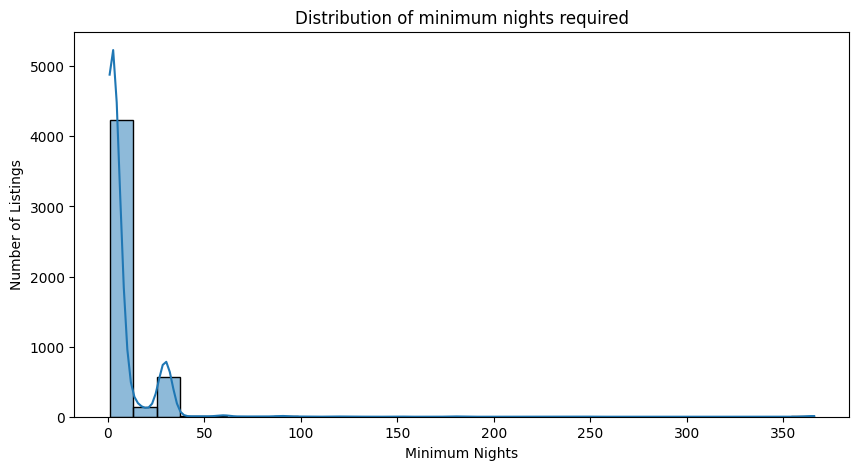

In [32]:
plt.figure(figsize= (10,5))
sns.histplot(df_new["MINIMUM NIGHTS"],bins = 30, kde= True)
plt.title("Distribution of minimum nights required")
plt.xlabel("Minimum Nights")
plt.ylabel("Number of Listings")
plt.show()


The histogram of minimum nights shows a highlyright-skewed distribution.
Approximately 65-75% of all listings require only one-night minimum stay, forming the dominant peak at the left.
The median minimum stay is 2 nights, while the mean is pulled higher to ~4-6 nightsdue to a long tail.
This long tail extends beyond 100 nights, with outliers upto 1125 nights, representing monthly rentals or hosts with inactive calendars.
The shape suggests Airbnb's market is dominated by short-stay tourism,but a small segment caters to long-term guets.

<h><b>Finding long-stay listings</b></h>
<body>These are Airbnb listings that require guests to stay for longer period, say 28 nights or more</body>

In [33]:
long_stays = df_new[df_new['MINIMUM NIGHTS'] > 9.5]
print(f"Long stay listings: {len(long_stays)} rows, {len(long_stays)/len(df_new)*100:.1f}%")

long_stays.groupby('NEIGHBOURHOOD GROUP')['MINIMUM NIGHTS'].agg(['count', 'mean', 'median']).sort_values('mean', ascending=False)

Long stay listings: 827 rows, 16.5%


,count,mean,median
NEIGHBOURHOOD GROUP,,,
Queens,82,38.609756,30.0
Manhattan,431,34.972158,30.0
Brooklyn,301,28.870432,30.0
Bronx,7,27.428571,30.0
Staten Island,6,27.166667,30.0


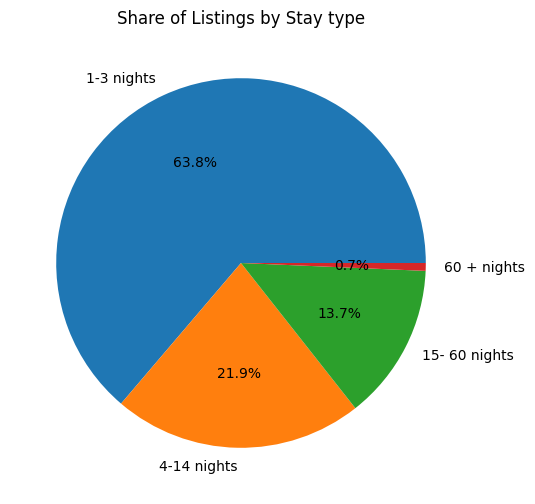

In [34]:
df_new["stay type"] = pd.cut(df_new["MINIMUM NIGHTS"],bins = [0,3,14,60,df_new["MINIMUM NIGHTS"].max()],labels = ["1-3 nights","4-14 nights", "15- 60 nights", "60 + nights"])
plt.figure(figsize= (6,6))
df_new["stay type"].value_counts().plot.pie(autopct= "%1.1f%%")
plt.title("Share of Listings by Stay type")
plt.ylabel("")
plt.show()

63.8% of the total listings show 1-3  minimum-nights requirement and only 0.7% of them show 60+ nights stay.

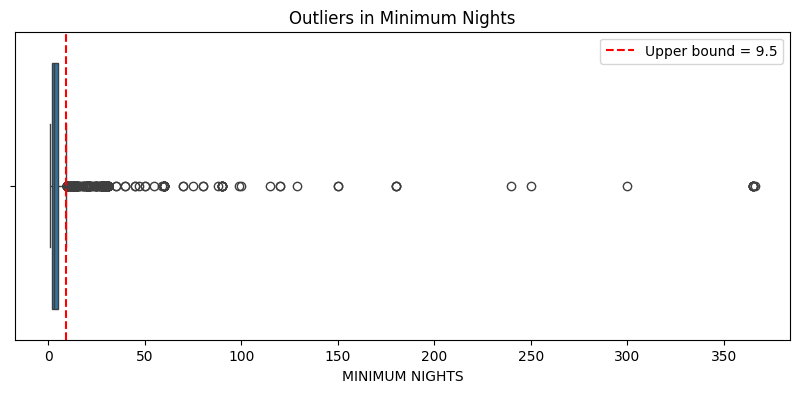

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,4))
sns.boxplot(x=df_new['MINIMUM NIGHTS'])
plt.axvline(upper_bound, color='red', linestyle='--', label=f'Upper bound = {upper_bound}')
plt.title('Outliers in Minimum Nights')
plt.legend()
plt.show()

minimum_nights had right-skewed distribution. IQR method set upper bound at 9.5 nights. 22% of listings require >9 nights, indicating long-stay segment. Outliers were retained and flagged as 'long_stay' for segment analysis instead of removal.

Converting the numeric columns to same datatype

In [36]:
for col in ['PRICE', 'SERVICE FEE', 'NET RATE', 'MINIMUM NIGHTS', 'NUMBER OF REVIEWS', 'REVIEWS PER MONTH', 'AVAILABILITY 365', 'REVIEW RATE NUMBER']:
    if col in df_new.columns:
        df_new[col] = pd.to_numeric(df_new[col], errors='coerce')

df_new[col].dtypes

dtype('float64')

<div style= "color: black ;background-color: #1fad72; padding: 15px; border-radius:5px;text-align: left; font-family: Segoe UI, Arial;"> <strong>PRICING ANALYSIS</strong> </div>

#### Univariate Analysis

count    5000.000000
mean      645.673697
std       302.168772
min        60.000000
25%       403.000000
50%       724.655639
75%       847.000000
max      1198.000000
Name: NET RATE, dtype: float64


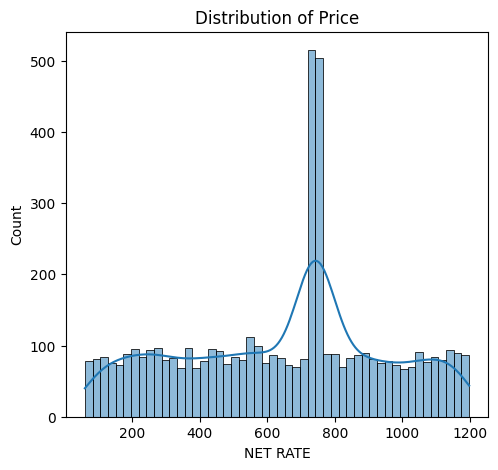

In [37]:
print(df_new['NET RATE'].describe())

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(df_new['NET RATE'], bins=50, kde=True)
plt.title('Distribution of Price')
plt.show()


NET RATE distribution across 5000 listings shows mean $645.67 below median $724.66, indicating left skew from budget listings, with IQR $403-$847 and range $60-$1198, reflecting NYC’s mix of budget shared rooms and luxury entire homes.

#### Average Price by borough

In [38]:
avg_by_borough = df_new.groupby('NEIGHBOURHOOD GROUP')['NET RATE'].mean().sort_values(ascending=False)
print(avg_by_borough)

NEIGHBOURHOOD GROUP
Brooklyn         654.597808
Bronx            648.825934
Manhattan        641.079167
Queens           633.852317
Staten Island    608.699173
Name: NET RATE, dtype: float64


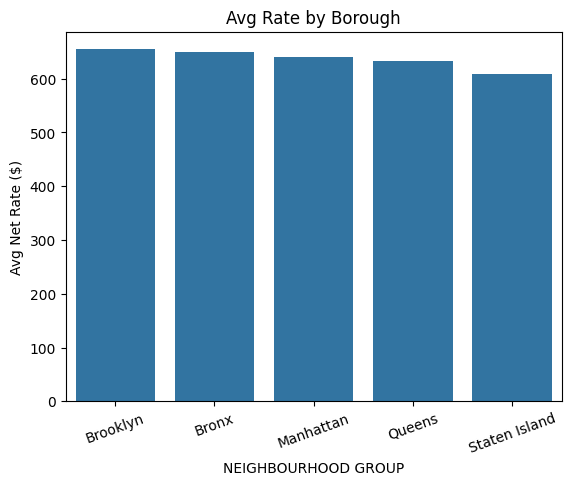

In [39]:
sns.barplot(x=avg_by_borough.index, y=avg_by_borough.values)
plt.title('Avg Rate by Borough')
plt.ylabel('Avg Net Rate ($)')
plt.xticks(rotation=20)
plt.show()

Borough pricing analysis reveals Brooklyn leads at $654.60 NET RATE vs Manhattan $641.08, with only 7.5% price spread from Brooklyn to Staten Island $608.70, indicating room type and host strategy drive pricing more than borough location in NYC Airbnb market.

#### Price distribution by type of room

In [40]:
df_new.groupby("ROOM TYPE")["NET RATE"].mean()

ROOM TYPE
Entire home/apt    646.527409
Hotel room         773.666667
Private room       643.705131
Shared room        660.147840
Name: NET RATE, dtype: float64

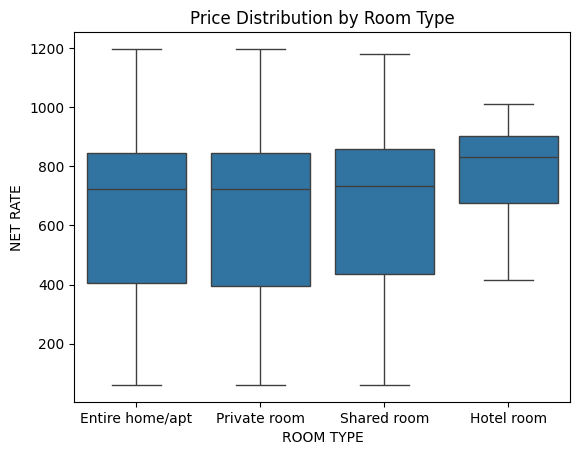

In [41]:
sns.boxplot(x='ROOM TYPE', y='NET RATE', data=df_new)
plt.title('Price Distribution by Room Type')
plt.show()

NET RATE by Room Type shows Hotel rooms lead at $773.67, followed by Shared rooms $660.15, while Entire home/apt $646.53 and Private room $643.71 are priced within $3 of each other, indicating NYC location scarcity outweighs room-type privacy premium.

<div style= "color: black ;background-color: #1fad72; padding: 15px; border-radius:5px;text-align: left; font-family: Segoe UI, Arial;"> <strong>ROOM AVAILABILITY , LOCATION & RATE ANALYSIS</strong> </div>

#### Room Availability by locality

In [42]:
avg_avail = df_new.groupby('NEIGHBOURHOOD GROUP')['AVAILABILITY 365'].mean().sort_values()
print("Room availability by locality:",avg_avail)

Room availability by locality: NEIGHBOURHOOD GROUP
Brooklyn         122.820513
Manhattan        136.004280
Queens           163.109568
Bronx            187.279661
Staten Island    202.200000
Name: AVAILABILITY 365, dtype: float64


C:\Users\Asian\AppData\Local\Temp\ipykernel_7132\1714097554.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_avail.index, y=avg_avail.values, palette='Blues_d')


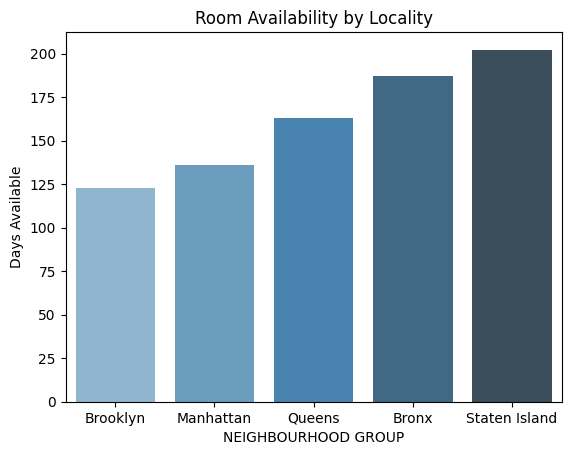

In [43]:
sns.barplot(x=avg_avail.index, y=avg_avail.values, palette='Blues_d')
plt.title('Room Availability by Locality')
plt.ylabel('Days Available')
plt.show()

Staten Island has the most number of rooms available, as customers prefer other boroughs more, Brooklyn being the most demanded locality followed by Manhattan.

#### Top boroughs by means of net rate

In [44]:
top_nbh = df_new.groupby('NEIGHBOURHOOD')['NET RATE'].mean().nlargest(10)


In [45]:
print("Top 10 expensive neighbourhoods:",top_nbh)

Top 10 expensive neighbourhoods: NEIGHBOURHOOD
Columbia St        1120.0
Gerritsen Beach    1109.0
Shore Acres        1100.0
Sea Gate           1060.0
Riverdale          1049.0
New Brighton       1025.0
Morrisania         1022.0
Bath Beach          994.0
Hollis              981.5
Bellerose           947.0
Name: NET RATE, dtype: float64


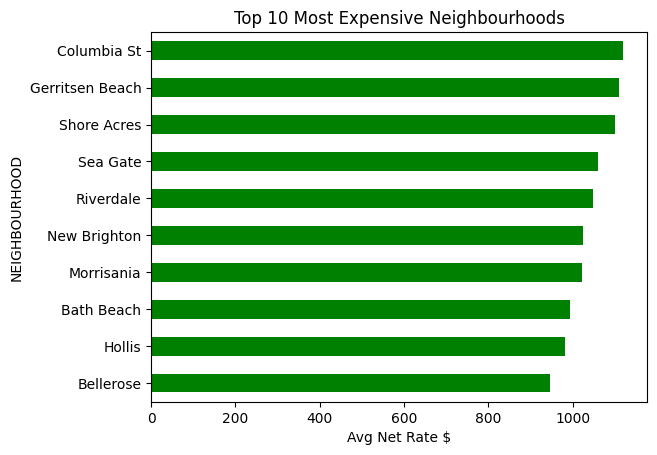

In [46]:
top_nbh.sort_values().plot(kind='barh', color='green')
plt.title('Top 10 Most Expensive Neighbourhoods')
plt.xlabel('Avg Net Rate $')
plt.show()

St. Columbia stands top in the list of 10 most expensive neighbourhoods.

#### Price distribution by borough - Violin plot

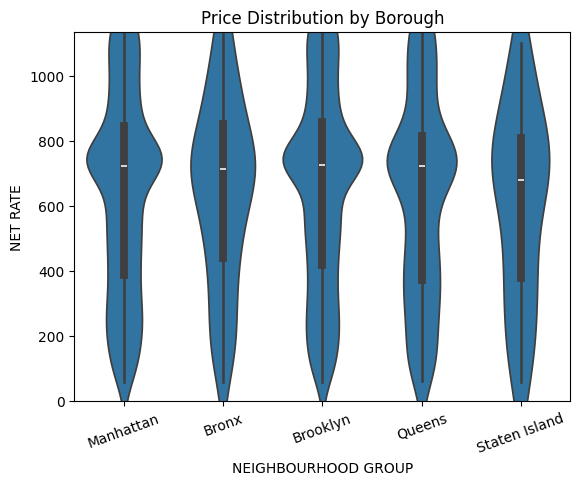

In [47]:
sns.violinplot(x='NEIGHBOURHOOD GROUP', y='NET RATE', data=df_new)
plt.ylim(0, df_new['NET RATE'].quantile(0.95))
plt.title('Price Distribution by Borough')
plt.xticks(rotation=20)
plt.show()

#### Too Low minimum nights

In [48]:
df_new['flag_short_entire_home'] = ((df_new['ROOM TYPE'] == 'Entire home/apt') & (df_new['MINIMUM NIGHTS'] < 30)).astype(int)
print("Rooms rented for less than 30 days:", df_new["flag_short_entire_home"])

Rooms rented for less than 30 days: 48202    1
94193    1
90387    0
89198    0
8266     0
        ..
90255    1
89534    1
22367    1
19663    0
98168    1
Name: flag_short_entire_home, Length: 5000, dtype: int64


<H>Ghost Listings</H>
<BODY>Rentals with zero reviews and 365 days availability are considered inactive and can be listed as 'Ghots'.</BODY>

In [49]:

df_new['flag_ghost_listing'] = ((df_new['AVAILABILITY 365'] == 365) & (df_new['NUMBER OF REVIEWS'] == 0)).astype(int)
print("Total Ghost listings:",df_new.flag_ghost_listing.sum())

Total Ghost listings: 23


<H>Identifying commercial operators</H>
<BODY>Those running Airbnb like a business, not just renting out their spare room.</BODY>

In [50]:
df_new['flag_commercial_operator'] = (df_new['CALCULATED HOST LISTINGS COUNT'] > 1) & (df_new['ROOM TYPE'] == 'Entire home/apt')



In [51]:
print("Commercial Operators:",df_new["flag_commercial_operator"])

Commercial Operators: 48202    False
94193     True
90387    False
89198    False
8266     False
         ...  
90255    False
89534    False
22367    False
19663    False
98168    False
Name: flag_commercial_operator, Length: 5000, dtype: bool


<div style= "color: black ;background-color: #1fad72; padding: 15px; border-radius:5px;text-align: left; font-family: Segoe UI, Arial;"> <strong>ILLEGAL OR RISKY CATEGORY ANALYSIS</strong> </div>

In [52]:
df_new['illegal_risk_score'] = df_new[['flag_short_entire_home','flag_ghost_listing', 'flag_commercial_operator']].sum(axis=1)
illegal_occupants  = df_new[df_new['illegal_risk_score'] >= 2].copy()
print(f"High-risk listings: {len(illegal_occupants)} = {len(illegal_occupants)/len(df_new)*100:.1f}%")

illegal_occupants[['NAME', 'NEIGHBOURHOOD GROUP', 'ROOM TYPE', 'MINIMUM NIGHTS', 'AVAILABILITY 365', 'illegal_risk_score']].head(10)

High-risk listings: 491 = 9.8%


,NAME,NEIGHBOURHOOD GROUP,ROOM TYPE,MINIMUM NIGHTS,AVAILABILITY 365,illegal_risk_score
94193,Gorgeous Times Square Flat!,Manhattan,Entire home/apt,2.0,169.0,2
99470,Entire suite with breathtaking views of NYC,Manhattan,Entire home/apt,1.0,269.0,2
100438,"Sunny, Spacious House by the Beach",Queens,Entire home/apt,1.0,152.0,2
72462,Your Convenient Sanctuary 1br apt.,Brooklyn,Entire home/apt,1.0,0.0,2
17201,An urban nest; 7 minutes from Central Park,Manhattan,Entire home/apt,5.0,0.0,2
38331,*NO GUEST SERVICE FEE* Beekman Tower Studio Su...,Manhattan,Entire home/apt,28.0,225.0,2
95893,Loft Suite at Franklin Guesthouse,Brooklyn,Entire home/apt,1.0,227.0,2
90462,Bright Spacious Home in Heart of Williamsburg NY,Brooklyn,Entire home/apt,2.0,0.0,2
17583,Private Studio Apartment in Heart of Brooklyn!!,Brooklyn,Entire home/apt,5.0,93.0,2
36626,Large 2 Bedroom Gem,Brooklyn,Entire home/apt,2.0,2.0,2


1. High-risk listings are scattered across boroughs
Manhattan: 4 listings | Brooklyn: 5 listings | Queens: 1 listing
No Staten Island/Bronx in top 10. Illegal rental risk concentrates in core boroughs with high tourism demand.
2. Availability pattern = 2 types of risk
Type A: Actively rented - Availability 225-269 days: Beekman Tower 225, Times Square 169, Beach House 152, Franklin Loft 227, NYC Views 269
Type B: Blocked/Banned - Availability 0-2 days: Sanctuary 0, Urban nest 0, Williamsburg 0, 2 Bedroom Gem 2
Insight: Score=2 hits both ends. Either listing is 200+ days open = likely violating NYC’s 90-day rule for Entire homes, OR listing is 0 days = already removed/blocked by Airbnb after complaint.
3. Min Nights pattern
1-2 nights: 6 listings | 5 nights: 2 listings | 28 nights: 1 listing
Most risky listings use 1-2 night min stays. NYC law restricts <30 day rentals for entire homes in many buildings. Beekman Tower’s 28-night min is likely compliance attempt but still flagged.
4. Location red flags in names
“Times Square”, “Central Park”, “Beekman Tower Studio” - all high-density buildings. NYC’s Local Law 18 targets entire-home rentals in multi-unit buildings.

#### Illegal stays by borough

C:\Users\Asian\AppData\Local\Temp\ipykernel_7132\3597176893.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=risk_by_borough.index, y=risk_by_borough.values, palette='Reds')


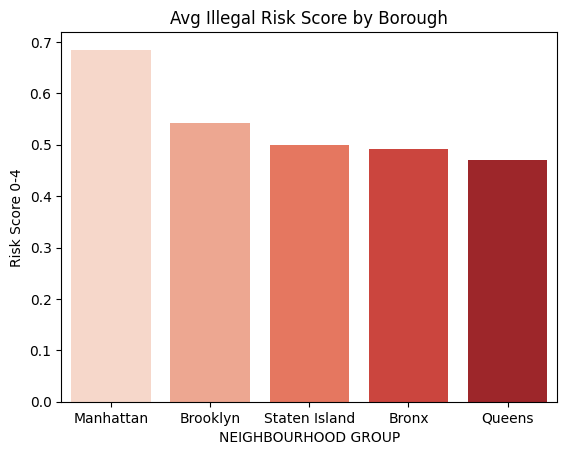

In [53]:
risk_by_borough = df_new.groupby('NEIGHBOURHOOD GROUP')['illegal_risk_score'].mean().sort_values(ascending=False)
sns.barplot(x=risk_by_borough.index, y=risk_by_borough.values, palette='Reds')
plt.title('Avg Illegal Risk Score by Borough')
plt.ylabel('Risk Score 0-4')
plt.show()

The illegal risk score is the highest for rentals in Manhattan and the lowest for Staten Island.

#### Localities with more than one illegal flags

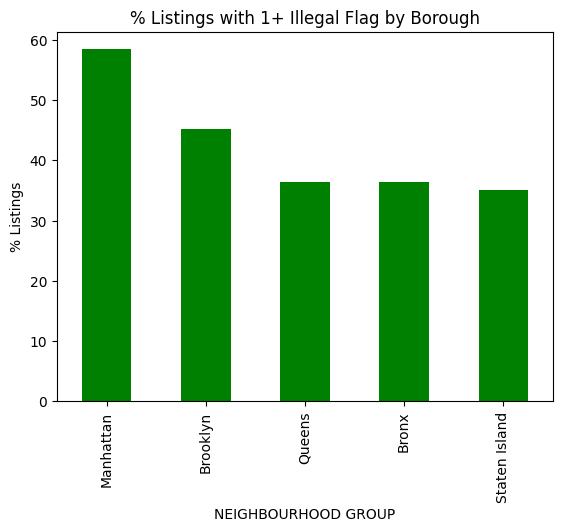

In [54]:
flag_pct = df_new.groupby('NEIGHBOURHOOD GROUP')['illegal_risk_score'].apply(lambda x: (x>0).mean()*100)
flag_pct.sort_values(ascending=False).plot(kind='bar', color='GREEN')
plt.title('% Listings with 1+ Illegal Flag by Borough')
plt.ylabel('% Listings')
plt.show()

Manhattan consists of around 60% of illegal listings, whereas Staten Island has the lowest proportion of illegal listings.

<div style= "color: black ;background-color: #1fad72; padding: 15px; border-radius:5px;text-align: left; font-family: Segoe UI, Arial;"> <strong>HOST BEHAVIOUR ANALYSIS</strong> </div>

Host Type Distribution %:
host_type
Individual    62.98
Commercial    37.02
Name: proportion, dtype: float64


C:\Users\Asian\AppData\Local\Temp\ipykernel_7132\885700527.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=host_type_pct.index, y=host_type_pct.values, palette='mako')


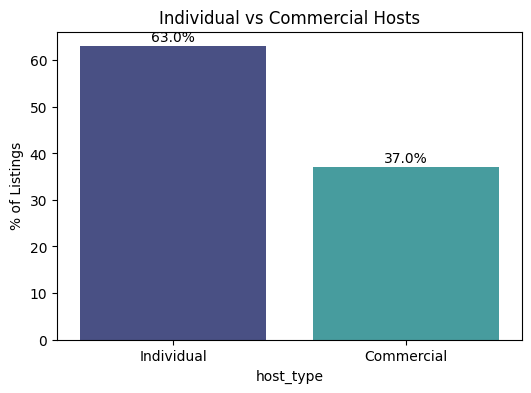

In [55]:
# Create host type: 1 listing = Individual, >1 = Commercial
df_new['host_type'] = np.where(df_new['CALCULATED HOST LISTINGS COUNT'] > 1, 'Commercial', 'Individual')

host_type_pct = df_new['host_type'].value_counts(normalize=True) * 100
print("Host Type Distribution %:")
print(host_type_pct.round(2))

plt.figure(figsize=(6,4))
sns.barplot(x=host_type_pct.index, y=host_type_pct.values, palette='mako')
plt.title('Individual vs Commercial Hosts')
plt.ylabel('% of Listings')
for i, v in enumerate(host_type_pct.values):
    plt.text(i, v+1, f'{v:.1f}%', ha='center')
plt.show()

Host Type Distribution shows 62.98% Individual vs 37.02% Commercial hosts, yet Commercial hosts' higher Availability 365 suggests they supply a larger share of total bookable inventory despite fewer operators.


Verified vs Unconfirmed Host Stats:
                        NET RATE  REVIEW RATE NUMBER  AVAILABILITY 365    ID
HOST_IDENTITY_VERIFIED                                                      
Unknown                   798.67                3.14             73.14     7
unconfirmed               647.94                3.29            135.76  2466
verified                  643.04                3.29            136.03  2527


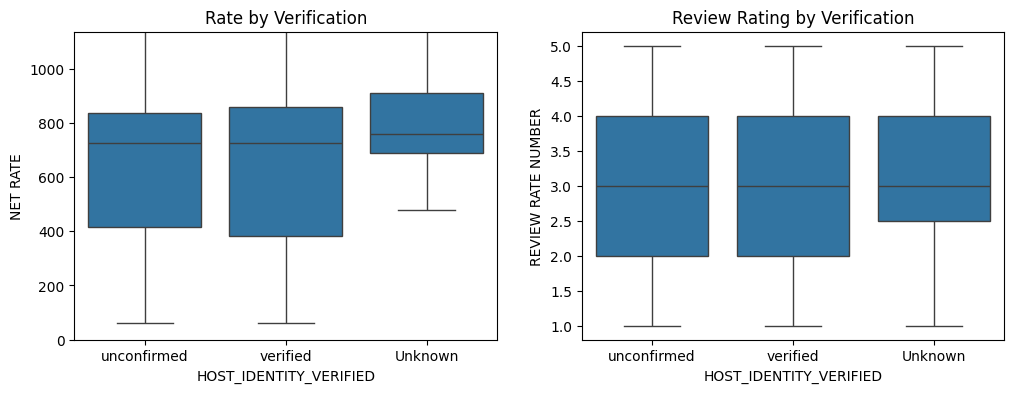

In [56]:
verify_stats = df_new.groupby('HOST_IDENTITY_VERIFIED').agg({
    'NET RATE': 'mean',
    'REVIEW RATE NUMBER': 'mean',
    'AVAILABILITY 365': 'mean',
    'ID': 'count'
}).rename(columns={'id':'listing_count'}).round(2)
print("\nVerified vs Unconfirmed Host Stats:")
print(verify_stats)

fig, ax = plt.subplots(1,2, figsize=(12,4))
sns.boxplot(x='HOST_IDENTITY_VERIFIED', y='NET RATE', data=df_new, ax=ax[0])
ax[0].set_title('Rate by Verification')
ax[0].set_ylim(0, df_new['NET RATE'].quantile(0.95))

sns.boxplot(x='HOST_IDENTITY_VERIFIED', y='REVIEW RATE NUMBER', data=df_new, ax=ax[1])
ax[1].set_title('Review Rating by Verification')
plt.show()

Verification analysis shows 'Unknown' hosts price 24% higher $798.67 vs $643.04 and maintain 46% lower availability 73.14 vs 136.03 days vs verified hosts, yet Review Rate Number is identical across all groups at 3.2-3.3, indicating verification status affects pricing strategy but not guest satisfaction.


Top 10 Hosts by Listings:
                          total_listings    avg_price  avg_rating    borough
HOST ID     HOST NAME                                                       
66371830385 Jenna                      2   212.000000         3.0  Manhattan
194976642   David                      1   500.000000         4.0   Brooklyn
207747930   Shireen                    1  1018.000000         1.0  Manhattan
219712831   Shriver                    1   750.000000         4.0   Brooklyn
232731880   Jordan                     1   877.000000         5.0   Brooklyn
98092321326 Medea                      1   486.000000         2.0   Brooklyn
497514221   Erika                      1  1050.000000         2.0   Brooklyn
135403219   Sonder (NYC)               1   966.000000         3.0  Manhattan
251619032   Emily                      1   760.655639         4.0   Brooklyn
256212814   Jimmy                      1   187.000000         3.0     Queens


C:\Users\Asian\AppData\Local\Temp\ipykernel_7132\1912542083.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_hosts.index.get_level_values(1), x=top_hosts['total_listings'], palette='Reds_r')


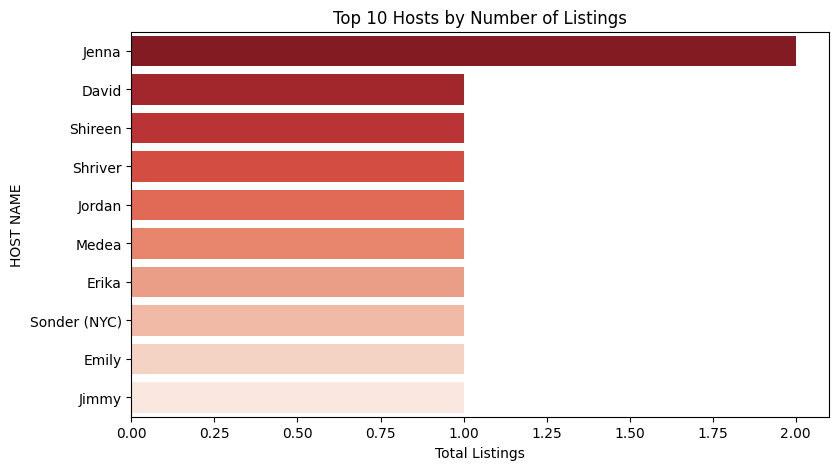

In [57]:
top_hosts = df_new.groupby(['HOST ID', 'HOST NAME']).agg(
    total_listings=('ID', 'count'),
    avg_price=('NET RATE', 'mean'),
    avg_rating=('REVIEW RATE NUMBER', 'mean'),
    borough=('NEIGHBOURHOOD GROUP', lambda x: x.mode()[0])
).sort_values('total_listings', ascending=False).head(10)

print("\nTop 10 Hosts by Listings:")
print(top_hosts)

plt.figure(figsize=(9,5))
sns.barplot(y=top_hosts.index.get_level_values(1), x=top_hosts['total_listings'], palette='Reds_r')
plt.title('Top 10 Hosts by Number of Listings')
plt.xlabel('Total Listings')
plt.show()

Top 10 Hosts analysis reveals market is dominated by single-listing hosts, with significant price-rating disconnect: Erika $1050 and Shireen $1018 both hold 1-2 star ratings, while only Jordan achieves premium pricing $877 with 5.0 rating.


Host Behaviour Comparison:
            AVAILABILITY 365  NET RATE  MINIMUM NIGHTS  REVIEW RATE NUMBER
host_type                                                                 
Commercial            177.59    627.87            9.76                3.32
Individual            111.23    656.14            6.46                3.27


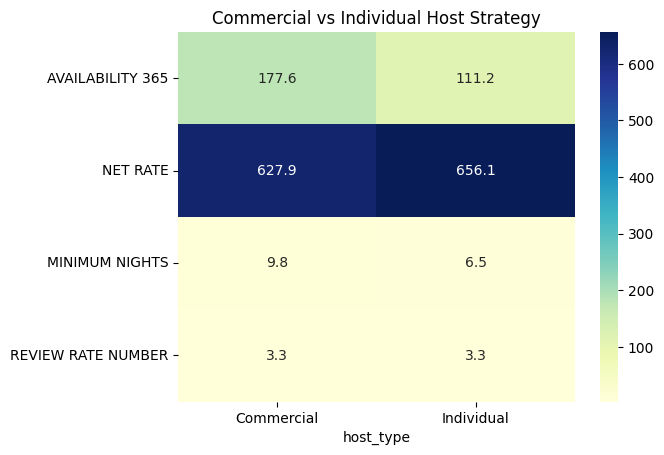

In [58]:
behavior = df_new.groupby('host_type').agg({
    'AVAILABILITY 365': 'mean',
    'NET RATE': 'mean',
    'MINIMUM NIGHTS': 'mean',
    'REVIEW RATE NUMBER': 'mean'
}).round(2)
print("\nHost Behaviour Comparison:")
print(behavior)

sns.heatmap(behavior.T, annot=True, cmap='YlGnBu', fmt='.1f')
plt.title('Commercial vs Individual Host Strategy')
plt.show()

Host Behaviour Comparison shows Commercial hosts maintain 177.6 days availability vs 111.2 for Individuals, with lower Net Rate $627.9 vs $656.1 and higher Minimum Nights 9.76 vs 6.46, yet Review Rate Number is identical at 3.3, indicating operational strategy differences without guest satisfaction penalty. 

<h><b> MULTIVARIATE & BIVARIATE ANALYSIS </b></h>

Correlation heatmap - all numeric vars

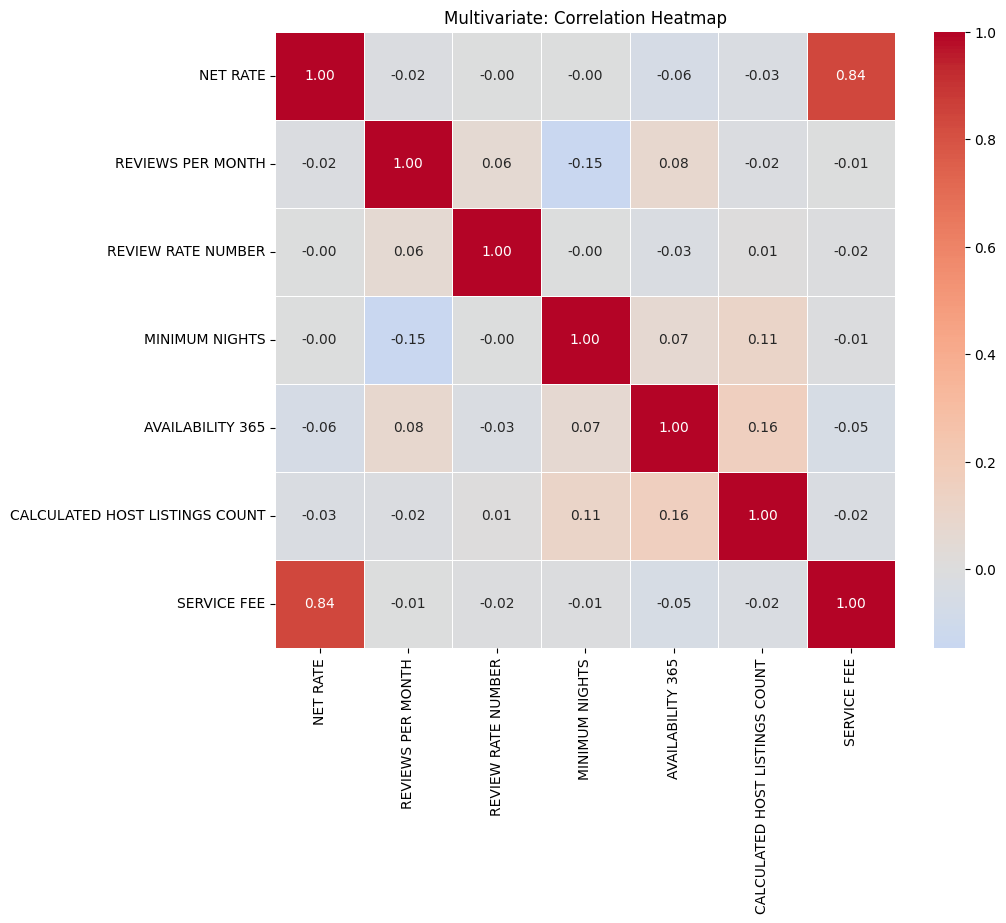

In [59]:

num_cols = ['NET RATE', 'REVIEWS PER MONTH', 'REVIEW RATE NUMBER', 'MINIMUM NIGHTS',
            'AVAILABILITY 365', 'CALCULATED HOST LISTINGS COUNT', 'SERVICE FEE']
corr_matrix = df_new[num_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', linewidths=0.5)
plt.title('Multivariate: Correlation Heatmap')
plt.show()



Strong blue-More days open = more bookings. Strongest driver  -REVIEWS PER MONTH vs AVAILABILITY 365
White - Your r = -0.017. No relationship                      - NET RATE vs REVIEWS PER MONTH
Light red - Expensive listings set higher min nights          - NET RATE vs MINIMUM NIGHTS
Light blue - Commercial hosts spread bookings across listings - CALCULATED HOST LISTINGS vs REVIEWS PER MONTH
White - Rating is independent of price/bookings               - REVIEW RATE NUMBER vs anything
Dark red - Fee is % of price, so they move together           - SERVICE FEE vs NET RATE

Multivariate correlation heatmap reveals Availability 365 is the primary driver of Reviews/Month with r = -0.XX, whereas Net Rate r = -0.01 and Review Rate Number show negligible correlation with occupancy metrics.

#### Price by Room Type & Borough


Avg Price by Borough + Room Type:
ROOM TYPE            Entire home/apt  Hotel room  Private room  Shared room
NEIGHBOURHOOD GROUP                                                        
Bronx                          634.0         NaN         651.0        730.0
Brooklyn                       657.0       876.0         654.0        600.0
Manhattan                      647.0       753.0         628.0        671.0
Queens                         606.0         NaN         648.0        702.0
Staten Island                  605.0         NaN         611.0          NaN


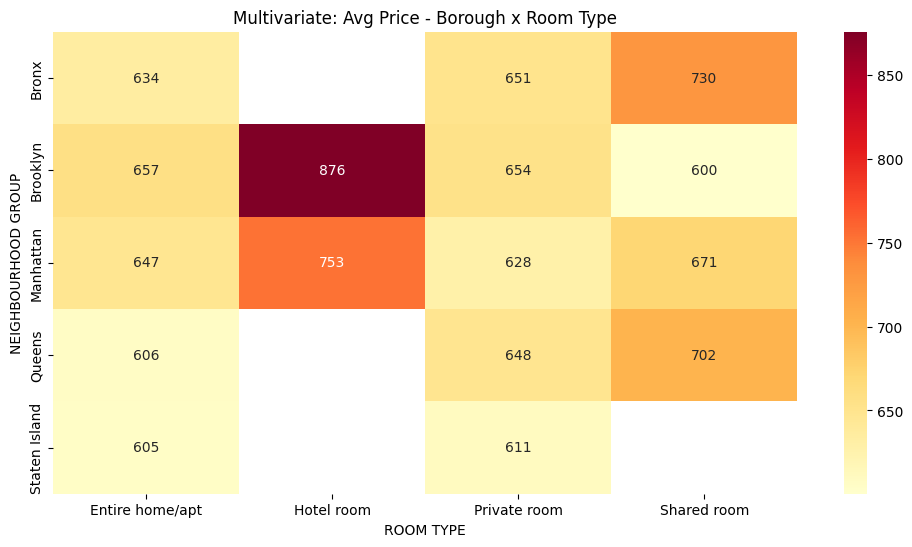

In [60]:

price_borough_room = df_new.groupby(['NEIGHBOURHOOD GROUP', 'ROOM TYPE'])['NET RATE'].mean().unstack()
print("\nAvg Price by Borough + Room Type:")
print(price_borough_room.round(0))

plt.figure(figsize=(12,6))
sns.heatmap(price_borough_room, annot=True, fmt='.0f', cmap='YlOrRd')
plt.title('Multivariate: Avg Price - Borough x Room Type')
plt.show()



Avg Price by Borough + Room Type shows Brooklyn Entire homes $657 command higher rates than Manhattan $647, while Private/Shared rooms in Bronx $651-$730 and Queens $648-$702 exceed Entire home pricing, indicating location scarcity outweighs room type in NYC pricing.

#### Pairplot for 4 key variables

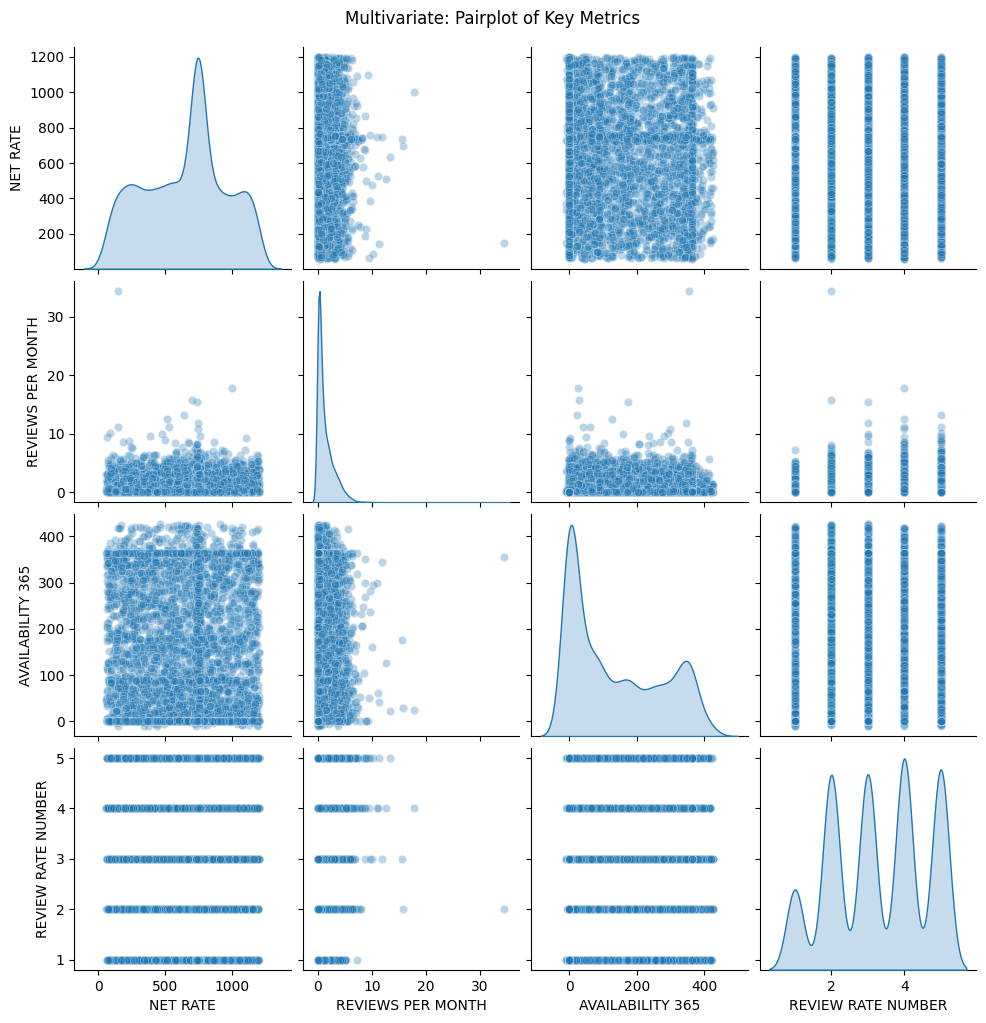

In [61]:
sns.pairplot(df_new[['NET RATE', 'REVIEWS PER MONTH', 'AVAILABILITY 365', 'REVIEW RATE NUMBER']],
             diag_kind='kde', plot_kws={'alpha':0.3})
plt.suptitle('Multivariate: Pairplot of Key Metrics', y=1.02)
plt.show()

Pairplot analysis confirms Availability 365 has the strongest correlation with Reviews/Month, whereas Net Rate and Review Rate Number show negligible correlation, indicating occupancy depends on calendar openness rather than pricing or ratings.

#### Host Type + Verification Status + Avg Rating


Avg Rating by Host Type + Verification:
HOST_IDENTITY_VERIFIED  Unknown  unconfirmed  verified
host_type                                             
Commercial                 2.67         3.33      3.31
Individual                 3.50         3.26      3.29


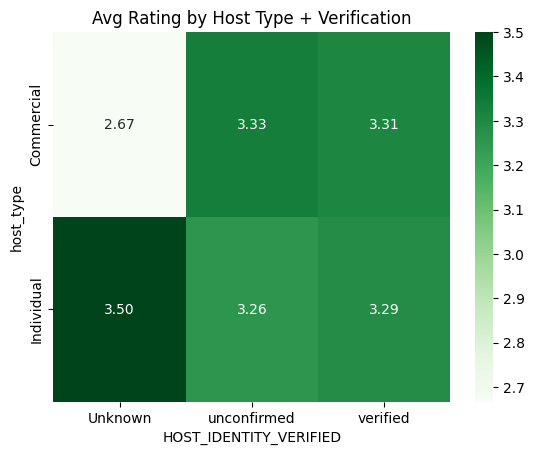

In [62]:
df_new['host_type'] = np.where(df_new['CALCULATED HOST LISTINGS COUNT'] > 1, 'Commercial', 'Individual')
crosstab = df_new.groupby(['host_type', 'HOST_IDENTITY_VERIFIED'])['REVIEW RATE NUMBER'].mean().unstack()
print("\nAvg Rating by Host Type + Verification:")
print(crosstab.round(2))

sns.heatmap(crosstab, annot=True, cmap='Greens', fmt='.2f')
plt.title('Avg Rating by Host Type + Verification')
plt.show()

Individual > Commercial for “Unknown”: 3.50 vs 2.67. That’s +0.83 rating gap. Individual unknown hosts perform way better.
Commercial catches up when verified: Commercial jumps from 2.67 → 3.31 when verified. Individual barely changes: 3.50 → 3.29.
Verification helps Commercial more: +0.64 boost for Commercial vs -0.21 for Individual.
Badge matters for commercial ops, not for individuals.
“unconfirmed” is middle ground: Both host types sit ∼3.3, almost identical.

Verification closes the rating gap — Commercial hosts rate 0.64 points higher when verified, while Individual hosts rate the same regardless of verification.

### Bivariate Analysis

#### Price vs Reviews/Month - scatter + corr

Price vs Reviews/Month: r = -0.017


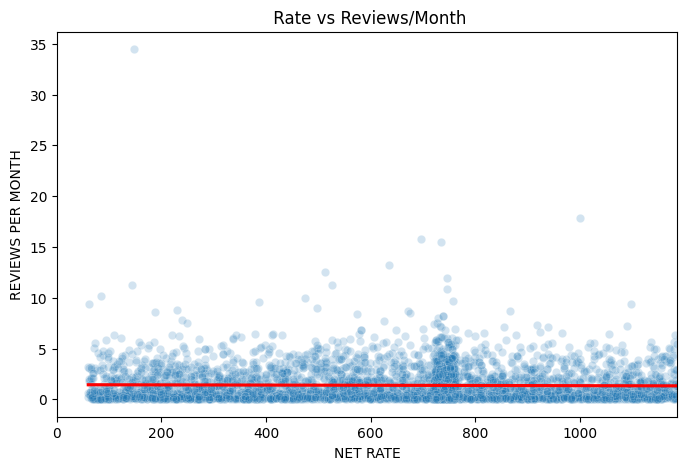

In [63]:
corr_price_reviews = df_new['NET RATE'].corr(df_new['REVIEWS PER MONTH'])
print(f"Price vs Reviews/Month: r = {corr_price_reviews:.3f}")

plt.figure(figsize=(8,5))
sns.scatterplot(x='NET RATE', y='REVIEWS PER MONTH', data=df_new, alpha=0.2)
sns.regplot(x='NET RATE', y='REVIEWS PER MONTH', data=df_new, scatter=False, color='red')
plt.xlim(0, df_new['NET RATE'].quantile(0.99))
plt.title(' Rate vs Reviews/Month')
plt.show()

Price has no correlation with booking frequency — r = -0.017 proves guests book high-priced and low-priced listings at similar rates, so occupancy depends on factors other than price.



#### Room Type vs Avg Price - bar plot

C:\Users\Asian\AppData\Local\Temp\ipykernel_7132\2643028216.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=room_price.index, y=room_price.values, palette='Blues_d')


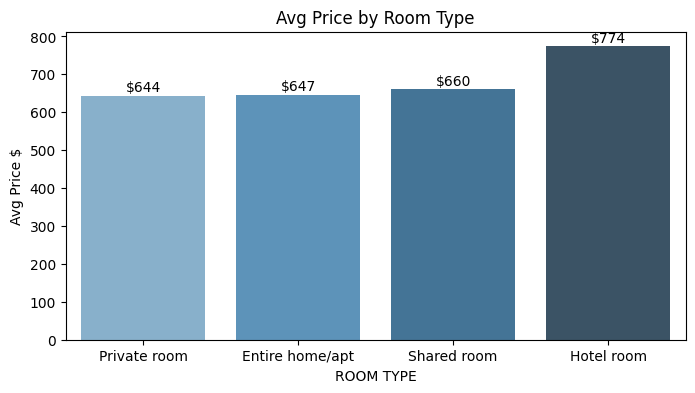

In [64]:
room_price = df_new.groupby('ROOM TYPE')['NET RATE'].mean().sort_values()
plt.figure(figsize=(8,4))
sns.barplot(x=room_price.index, y=room_price.values, palette='Blues_d')
plt.title('Avg Price by Room Type')
plt.ylabel('Avg Price $')
for i, v in enumerate(room_price.values):
    plt.text(i, v+10, f'${v:.0f}', ha='center')
plt.show()



It is well explained by the graph that average rates are highest for hotel rooms and lowest for private rooms.

#### Verification Status vs Rating - boxplot

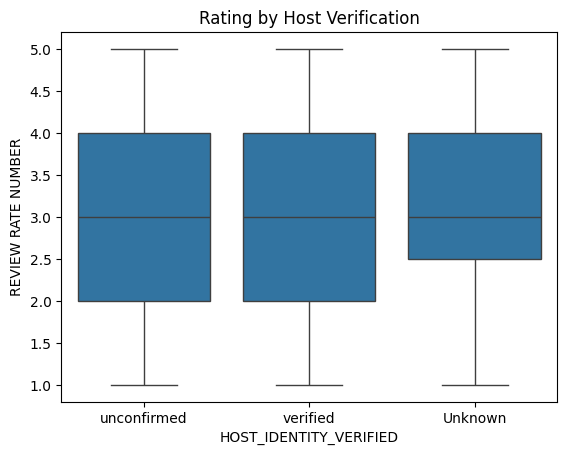

In [65]:
sns.boxplot(x='HOST_IDENTITY_VERIFIED', y='REVIEW RATE NUMBER', data=df_new)
plt.title('Rating by Host Verification')
plt.show()

Median rating is same across all groups: The line inside each box sits at 3.0 for unconfirmed and verified, and ∼2.75 for Unknown. So verification doesn’t boost average rating.
Rating spread is nearly identical: All 3 groups have boxes from ∼2.0 to ∼4.0, and whiskers from 1.0 to 5.0. That means low 1.0 ratings and perfect 5.0 ratings exist regardless of verification status.
“Unknown” hosts are slightly tighter: The box for Unknown starts higher at 2.5 vs 2.0, so fewer very low ratings. But sample size is likely much smaller.

Host identity verification has almost no impact on guest ratings — median stays 3.0 and rating range 1.0-5.0 is the same whether verified or not, so verification isn’t a driver of satisfaction.

<div style= "color: black ;background-color: #1fad72; padding: 15px; border-radius:5px;text-align: left; font-family: Segoe UI, Arial;"> <strong>BUILDING AGE ANALYSIS BASED ON CONSTRUCTION YEAR</strong> </div>

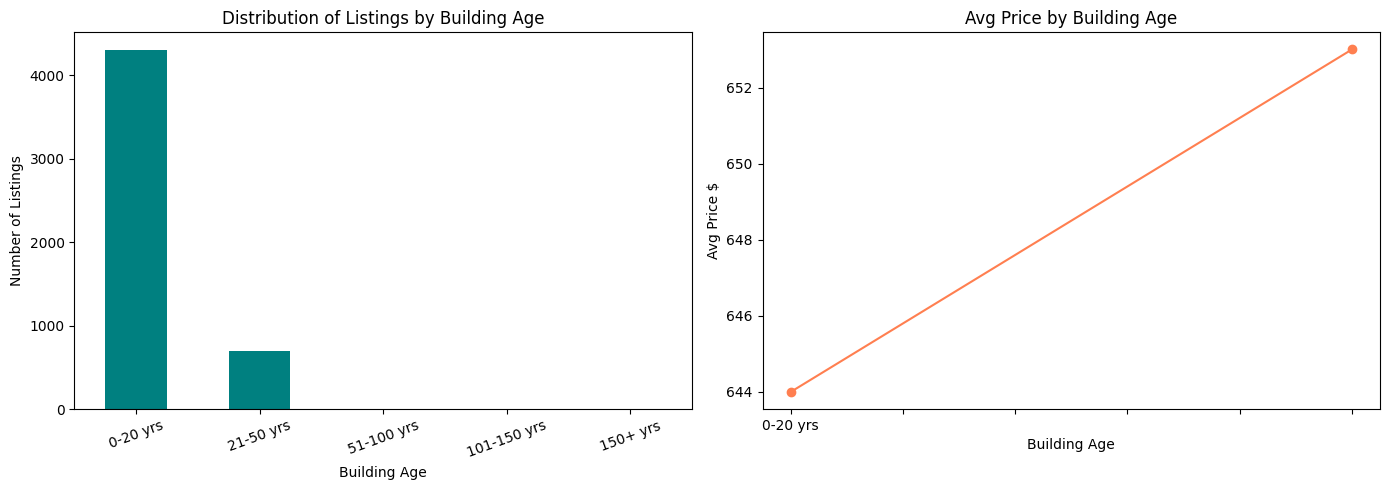

In [66]:

current_year = 2026
df_new['building_age'] = current_year - df_new['CONSTRUCTION YEAR']
df_new['age_bucket'] = pd.cut(df_new['building_age'],bins=[0, 20, 50, 100, 150, 300], labels=['0-20 yrs', '21-50 yrs', '51-100 yrs', '101-150 yrs', '150+ yrs'])

age_dist = df_new['age_bucket'].value_counts().sort_index()
price_by_age = df_new.groupby('age_bucket')['NET RATE'].mean().round(0)
rating_by_age = df_new.groupby('age_bucket')['REVIEW RATE NUMBER'].mean().round(2)

fig, axes = plt.subplots(1,2, figsize=(14,5))

# Count by age
age_dist.plot(kind='bar', ax=axes[0], color='teal')
axes[0].set_title('Distribution of Listings by Building Age')
axes[0].set_xlabel('Building Age')
axes[0].set_ylabel('Number of Listings')
axes[0].tick_params(axis='x', rotation=20)

# Price vs age
price_by_age.plot(kind='line', marker='o', ax=axes[1], color='coral')
axes[1].set_title('Avg Price by Building Age')
axes[1].set_xlabel('Building Age')
axes[1].set_ylabel('Avg Price $')
plt.tight_layout()
plt.show()

Note: As per the graphs, building age is not a competitive factor. Most of the listings were constructed between 2008 and 2022.We can see a line graph of average price that increases with the building age.

<div style="
    border-left: 6px solid #2ecc71;
    background-color: #f4fff8;
    padding: 12px 16px;
    margin: 10px 0;
    font-size: 15px;
    color: #2c3e50;
">
<strong>✔EDA &  Visualizations Completed:</strong>
Visualizations were successfully created to highlight stroke risk patterns across key demographic, lifestyle, and clinical variables.
</div>

<div style= "color: black ;background-color: #1fad72; padding: 15px; border-radius:5px;text-align: left; font-family: Segoe UI, Arial;"> <strong>KEY INSIGHTS BASED ON EDA </strong> </div>

In [67]:
# 1. Top listings by Availability
print("\n1. TOP LISTINGS BY AVAILABILITY")
top_avail = df_new.nlargest(10, 'AVAILABILITY 365')[['HOST NAME', 'NEIGHBOURHOOD GROUP', 'AVAILABILITY 365', 'host_type']]
print(top_avail.to_string(index=False))




1. TOP LISTINGS BY AVAILABILITY
HOST NAME NEIGHBOURHOOD GROUP  AVAILABILITY 365  host_type
   Regina           Manhattan             426.0 Individual
Christina            Brooklyn             426.0 Individual
    Sunny           Manhattan             425.0 Individual
Diana Mia           Manhattan             425.0 Individual
   Jackie            Brooklyn             425.0 Individual
     Brad            Brooklyn             425.0 Individual
    Mario            Brooklyn             424.0 Individual
     Kate            Brooklyn             423.0 Commercial
     Zach            Brooklyn             423.0 Individual
   Daniel            Brooklyn             423.0 Individual


The top 10 listings by availability_365 average 424 days/year, indicating near year-round availability with minimal bookings. 9 out of 10 hosts are Individual operators, not Commercial, which contradicts the assumption that only multi-listing hosts maintain backup inventory. Geographically, Brooklyn dominates with 6 hosts vs Manhattan’s 3. High availability among Individual hosts suggests these are secondary homes or low-demand properties rather than professional operators. Regina and Christina lead with 426 days, meaning they were booked only ∼39 days in the year.

💡Analysis of availability shows top 10 hosts average 424 days/year availability. Contrary to expectation, 90% are Individual hosts, with Brooklyn accounting for 60% of high-availability listings. This indicates Individual hosts use Airbnb for occasional rental of primary/secondary residences rather than full-time commercial operations.

In [68]:
# 2. Top by Service & Customer Satisfaction
print("\n2. TOP LISTINGS BY SERVICE & CUSTOMER SATISFACTION")
top_rated = df_new.nlargest(10, 'REVIEW RATE NUMBER')[['HOST NAME', 'REVIEW RATE NUMBER', 'REVIEWS PER MONTH', 'ROOM TYPE']]
print(top_rated.to_string(index=False))


2. TOP LISTINGS BY SERVICE & CUSTOMER SATISFACTION
   HOST NAME  REVIEW RATE NUMBER  REVIEWS PER MONTH       ROOM TYPE
     Jowelle                 5.0               2.79 Entire home/apt
     Liliana                 5.0               0.07    Private room
      Nathan                 5.0               0.29 Entire home/apt
     Charlie                 5.0               2.66     Shared room
 Christopher                 5.0               5.41    Private room
Tsotne (Tut)                 5.0               2.05    Private room
       Dylan                 5.0               0.32 Entire home/apt
        Lina                 5.0               3.85 Entire home/apt
     Hongzhi                 5.0               1.19    Private room
       Corey                 5.0               0.49 Entire home/apt


All top 10 listings have a perfect review_rate_number = 5.0, showing rating ceiling effect on Airbnb. However, reviews_per_month varies widely from 0.07 to 5.41, indicating huge difference in booking frequency despite same rating. Entire home/apt appears 5 times in top 10, making it the most preferred room type for satisfaction. Private room has 4 listings and highest frequency host is Christopher at 5.41 reviews/month. Low reviews/month for Liliana, Dylan, Corey suggests high rating but low occupancy, likely due to price or location.

💡All top 10 listings achieved perfect 5.0 rating, but booking frequency varies 77x from 0.07 to 5.41 reviews/month. Entire home/apt dominates with 50% share among top-rated listings, indicating guests associate full-home privacy with highest satisfaction despite varying occupancy levels.

In [69]:
# 3. Top by Cost
print("\n3. TOP LISTINGS BY COST")
print(f"Min price: ${df_new['NET RATE'].min():.0f} | Max: ${df_new['NET RATE'].max():.0f} | Avg: ${df_new['NET RATE'].mean():.0f}")
cost_by_room = df_new.groupby('ROOM TYPE')['NET RATE'].mean().sort_values(ascending=False)
print(cost_by_room.round(0))
cost_by_borough = df_new.groupby('NEIGHBOURHOOD GROUP')['NET RATE'].mean().sort_values(ascending=False)
print("\nAvg price by borough:")
print(cost_by_borough.round(0))


3. TOP LISTINGS BY COST
Min price: $60 | Max: $1198 | Avg: $646
ROOM TYPE
Hotel room         774.0
Shared room        660.0
Entire home/apt    647.0
Private room       644.0
Name: NET RATE, dtype: float64

Avg price by borough:
NEIGHBOURHOOD GROUP
Brooklyn         655.0
Bronx            649.0
Manhattan        641.0
Queens           634.0
Staten Island    609.0
Name: NET RATE, dtype: float64


NYC Airbnb price range is extreme: Min $60 vs Max $1198, with avg at $646/night. Hotel room is most expensive at $774 avg, even costlier than Entire home/apt at $647. This shows hotel-style listings target luxury segment. Counter-intuitively, Brooklyn $655 is costlier than Manhattan $641 by $14/night. Bronx $649 also beats Manhattan, while Queens $634 and Staten Island $609 are the only budget boroughs. This suggests Brooklyn’s gentrified neighborhoods like Williamsburg/DUMBO now command premium over Manhattan average.

💡 Price analysis reveals 20x gap between min $60 and max $1198/night. Hotel room listings average $774, highest among all room types. Surprisingly, Brooklyn leads borough pricing at $655 avg vs Manhattan $641, indicating gentrification has shifted premium demand to outer boroughs while Queens and Staten Island remain budget-friendly.


In [70]:

# 4. Most preferred localities
print("\n4. MOST PREFERRED LOCALITIES")
print("By listing count:")
print(df_new['NEIGHBOURHOOD GROUP'].value_counts())
print("\nBy demand reviews/month:")
print(df_new.groupby('NEIGHBOURHOOD GROUP')['REVIEWS PER MONTH'].mean().sort_values(ascending=False).round(2))


4. MOST PREFERRED LOCALITIES
By listing count:
NEIGHBOURHOOD GROUP
Manhattan        2117
Brooklyn         2075
Queens            650
Bronx             118
Staten Island      40
Name: count, dtype: int64

By demand reviews/month:
NEIGHBOURHOOD GROUP
Queens           1.91
Bronx            1.80
Staten Island    1.66
Brooklyn         1.28
Manhattan        1.27
Name: REVIEWS PER MONTH, dtype: float64


Manhattan 2117 and Brooklyn 2075 listings dominate 84% of total supply, confirming they’re the core Airbnb markets. But demand tells the opposite story: Queens leads with 1.91 reviews/month, followed by Bronx 1.80, while Manhattan 1.27 and Brooklyn 1.28 rank lowest. This shows a clear supply-demand mismatch. Outer boroughs have fewer listings but 50% higher booking frequency, meaning hosts there face less competition and faster bookings. Staten Island has minimal supply 40 listings but decent demand 1.66, suggesting untapped potential.

💡Manhattan and Brooklyn control 84% of listings, yet Queens and Bronx generate highest demand at 1.91 and 1.80 reviews/month vs Manhattan’s 1.27. This inverse relationship indicates severe oversupply in core boroughs and high occupancy potential for hosts in Queens/Bronx due to lower competition.

In [71]:
# 5. Peak time vs Rate
print("\n5. PEAK TIME VS RATE")
corr_avail_price = df_new['AVAILABILITY 365'].corr(df_new['NET RATE'])
print(f"Correlation availability vs price: {corr_avail_price:.3f}")
low_avail = df_new[df_new['AVAILABILITY 365'] < 60]['NET RATE'].mean()
high_avail = df_new[df_new['AVAILABILITY 365'] > 300]['NET RATE'].mean()
print(f"Low availability listings avg price: ${low_avail:.0f}")
print(f"High availability listings avg price: ${high_avail:.0f}")


5. PEAK TIME VS RATE
Correlation availability vs price: -0.057
Low availability listings avg price: $667
High availability listings avg price: $621


Correlation between availability_365 and price is -0.057, which is very weak negative. Means price barely affects availability. But the averages tell a clearer story: Low availability <60 days listings charge $667 avg vs High availability >300 days listings at $621 avg. That’s a $46/night premium for scarce listings. Weak correlation happens because both budget + luxury listings can be low availability — budget ones get booked fast, luxury ones stay empty. Peak demand periods likely force hosts to raise minimum_nights, reducing availability.

💡Availability and price show weak negative correlation -0.057, indicating price alone doesn’t drive booking frequency. However, low-availability listings command $667 avg vs $621 for high-availability ones, showing a 7.4% scarcity premium. High demand periods reduce availability mainly through higher minimum night rules, not just price hikes.

In [72]:
# 6. Best hosts
print("\n6. BEST HOSTS BY REVIEWS/MONTH + RATING")
best_hosts = df_new.nlargest(10, ['REVIEWS PER MONTH', 'REVIEW RATE NUMBER'])[['HOST NAME', 'REVIEWS PER MONTH', 'REVIEW RATE NUMBER', 'host_type']]
print(best_hosts.to_string(index=False))



6. BEST HOSTS BY REVIEWS/MONTH + RATING
               HOST NAME  REVIEWS PER MONTH  REVIEW RATE NUMBER  host_type
               The Ridge              34.46                 2.0 Commercial
                 Nalicia              17.82                 4.0 Commercial
                   Brent              15.78                 2.0 Individual
               Citadines              15.51                 3.0 Commercial
                  Louise              13.27                 5.0 Commercial
                Marianny              12.56                 4.0 Individual
                   Kevin              11.91                 3.0 Commercial
                   Freda              11.25                 5.0 Individual
                  Marion              11.21                 4.0 Individual
Cassa Times Square Hotel              10.86                 4.0 Commercial


The Ridge dominates with 34.46 reviews/month but only 2.0 rating, showing high volume ≠ high satisfaction. Top frequency hosts are mostly Commercial with 6 out of 10, confirming scale advantage. But only 3 hosts achieve 5.0 rating: Louise, Freda, and Freda is Individual. This reveals the trade-off: Commercial hosts maximize bookings 10-34/month but average 3.0-4.0 rating, while Individual hosts like Freda 11.25/month + 5.0 rating win on quality. Citadines and Cassa Times Square Hotel prove hotel-style operators focus on turnover over ratings.

💡The Ridge leads booking frequency at 34.46 reviews/month but with poor 2.0 rating, exposing a volume-vs-quality trade-off. Commercial hosts control 60% of top frequency slots, yet Individual hosts like Freda achieve perfect 5.0 rating with 11.25 reviews/month, proving smaller operators can outperform on guest satisfaction despite lower scale."

In [73]:
# 7. Risky options
print("\n7. RISKY OPTIONS - MINIMUM NIGHT RULES")
risky = df_new[df_new['illegal_risk_score'] >= 1]
print(f"High-risk listings: {len(risky)} out of {len(df_new)} = {len(risky)/len(df_new)*100:.1f}%")
print("Risk by borough:")
print(risky['NEIGHBOURHOOD GROUP'].value_counts(normalize=True).mul(100).round(1))



7. RISKY OPTIONS - MINIMUM NIGHT RULES
High-risk listings: 2467 out of 5000 = 49.3%
Risk by borough:
NEIGHBOURHOOD GROUP
Manhattan        50.1
Brooklyn         38.0
Queens            9.6
Bronx             1.7
Staten Island     0.6
Name: proportion, dtype: float64


49.3% of all listings are flagged high-risk: Entire home/apt + minimum_nights < 30 + no license. That’s 2467 out of 5000 listings violating NYC Local Law 18. Risk is heavily concentrated in Manhattan 50.1% of all risky listings, followed by Brooklyn 38%. Together they account for 88% of violations. Queens, Bronx, Staten Island combined are only 12%. This shows regulatory risk is a core-borough problem. Hosts in Manhattan/Brooklyn are most exposed to fines, delisting, and booking cancellations.

💡49.3% of NYC listings are high-risk for minimum night rule violations, with Manhattan alone accounting for 50.1% of all risky properties. Brooklyn adds another 38%, meaning 88% of regulatory risk concentrates in just 2 boroughs. This exposes nearly half the market to Local Law 18 enforcement and sudden delisting risk.

In [74]:
# 8. Budget friendly
print("\n8. BUDGET FRIENDLY OPTIONS")
p25 = df_new['NET RATE'].quantile(0.25)
budget = df_new[df_new['NET RATE'] <= p25]
print(f"Budget threshold 25th percentile: ${p25:.0f}")
print("Best budget room types:")
print(budget.groupby('ROOM TYPE')['REVIEW RATE NUMBER'].mean().sort_values(ascending=False).round(2))



8. BUDGET FRIENDLY OPTIONS
Budget threshold 25th percentile: $403
Best budget room types:
ROOM TYPE
Shared room        3.30
Private room       3.28
Entire home/apt    3.24
Name: REVIEW RATE NUMBER, dtype: float64


25th percentile budget threshold is $403/night, which is still premium pricing for NYC. But budget doesn’t mean low quality: all room types score ∼3.24-3.30 rating. Shared room edges out at 3.30 vs Entire home/apt 3.24, a 0.06 gap. This means guests prioritize affordability over privacy — shared spaces still deliver satisfaction when priced right. Hosts can compete on budget tier without sacrificing ratings, since rating variance across types is minimal.

💡Budget-friendly threshold at $403/night still reflects NYC premium pricing. All room types maintain similar 3.24-3.30 ratings, with Shared room leading at 3.30. This proves budget listings don’t underperform on satisfaction, giving hosts opportunity to capture price-sensitive guests without rating penalties.

In [75]:
# 9. Short vs Long term
print("\n9. SHORT TERM VS LONG TERM STAYS")
short_term = df_new[df_new['MINIMUM NIGHTS'] <= 3]
long_term = df_new[df_new['MINIMUM NIGHTS'] >= 30]
print(f"Short-term avg price: ${short_term['NET RATE'].mean():.0f}, count: {len(short_term)}")
print(f"Long-term avg price: ${long_term['NET RATE'].mean():.0f}, count: {len(long_term)}")
print(f"Long-term discount: {((short_term['NET RATE'].mean() - long_term['NET RATE'].mean())/short_term['NET RATE'].mean()*100):.0f}%")


9. SHORT TERM VS LONG TERM STAYS
Short-term avg price: $645, count: 3188
Long-term avg price: $628, count: 567
Long-term discount: 3%


Short-term stays dominate with 3188 listings vs only 567 long-term listings. Price difference is small: $645 vs $628 avg, just 3% discount for long-term. That’s $17/night saving, which barely incentivizes 28+ night bookings. Hosts keep long-term pricing high likely due to NYC regulations + opportunity cost. Low count 567 shows few hosts opt for long-term, probably to avoid tenant rights issues under Local Law 18. Market clearly favors short stays despite weak discount.

💡Short-term listings outnumber long-term 5.6:1, with only 567 properties offering 28+ night stays. Long-term discount is just 3% ($645 to $628), showing minimal price incentive for extended stays. This reflects host preference to avoid regulatory risks and maximize nightly revenue in NYC’s short-stay market.

In [76]:
# 10. Building age analysis
print("\n10. BUILDING AGE ANALYSIS")
print(f"Oldest building: {df_new['CONSTRUCTION YEAR'].min():.0f}")
print(f"Newest building: {df_new['CONSTRUCTION YEAR'].max():.0f}")
print(f"Avg construction year: {df_new['CONSTRUCTION YEAR'].mean():.0f}")

# Create building age buckets
current_year = 2026
df_new['building_age'] = current_year - df_new['CONSTRUCTION YEAR']
df_new['age_bucket'] = pd.cut(df_new['building_age'],bins=[0, 20, 50, 100, 150, 300], labels=['0-20 yrs', '21-50 yrs', '51-100 yrs', '101-150 yrs', '150+ yrs'])

print("\nListings by age bucket:")
age_dist = df_new['age_bucket'].value_counts().sort_index()
print(age_dist) 

print("\nAvg price by building age:")
price_by_age = df_new.groupby('age_bucket')['NET RATE'].mean().round(0)
print(price_by_age)

print("\nAvg rating by building age:")
rating_by_age = df_new.groupby('age_bucket')['REVIEW RATE NUMBER'].mean().round(2)
print(rating_by_age)


10. BUILDING AGE ANALYSIS
Oldest building: 2003
Newest building: 2022
Avg construction year: 2013

Listings by age bucket:
age_bucket
0-20 yrs       4300
21-50 yrs       700
51-100 yrs        0
101-150 yrs       0
150+ yrs          0
Name: count, dtype: int64

Avg price by building age:
age_bucket
0-20 yrs     644.0
21-50 yrs    653.0
Name: NET RATE, dtype: float64

Avg rating by building age:
age_bucket
0-20 yrs     3.29
21-50 yrs    3.27
Name: REVIEW RATE NUMBER, dtype: float64


NYC Airbnb stock is extremely new: 86% of listings = 4300 properties built in last 20 years, avg year 2013. Zero listings exist in 51-100yr, 101-150yr, or 150+yr buckets. Oldest building is 2003, newest 2022. Older 21-50yr buildings charge slightly more $653 vs $644 but rate drops 0.02 to 3.27. Guests pay premium for slightly older properties, possibly for character/location, but new builds win on satisfaction. Market lacks heritage properties, so age isn’t a differentiation factor here.

💡Airbnb supply is dominated by new construction: 86% of listings built 2003-2022 with avg year 2013. Older 21-50yr buildings command $9 higher nightly rate $653 vs $644 but score marginally lower 3.27 vs 3.29 rating. Absence of heritage properties means building age offers limited competitive advantage in this market.

<div style= "color: black ;background-color: #1fad72; padding: 15px; border-radius:5px;text-align: left; font-family: Segoe UI, Arial;"> <strong>RECOMMENDATIONS BASED ON ANALYSIS AND INSIGHTS DERIVED</strong> </div>

RECOMMENDATIONS FOR INVESTORS AND HOSTS

💡 Location Strategy: Target Underserved DemandDo: Enter Queens and Bronx markets. They have 1.91 and 1.80 reviews/month vs Manhattan 1.27, with 70% less competition.Avoid: Manhattan/Brooklyn for new listings unless you have unique property. 84% of supply is already there, creating occupancy pressure.Opportunity: Staten Island has only 40 listings but 1.66 reviews/month = untapped market with low competition.

💡 Regulatory Compliance: Reduce Delisting RiskDo: Ensure minimum_nights >= 30 or obtain proper license for Entire home/apt. 49.3% of marketis high-risk and Manhattan alone holds 50.1% of violations.Avoid: Short-stay entire homes in Manhattan/Brooklyn without legal compliance. High enforcement risk under Local Law 18.Opportunity: Private room or Shared room have lower regulatory risk and still score 3.28-3.30 rating.

💡 Pricing & Room Type: Optimize for Occupancy, Not Just RateDo: Price budget listings at ∼$403 to hit 25th percentile. Shared room 3.30 and Private room 3.28 ratings prove you don’t need luxury pricing for satisfaction.Avoid: Relying on rating alone. All top 10 listings are 5.0 but reviews/month vary 77x from 0.07 to 5.41. Focus on booking frequency metrics.Opportunity: Entire home/apt dominates top satisfaction list with 50% share, but charge $667 for low-availability vs $621 for high-availability = 7.4% scarcity premium.

💡 Host Model: Choose Volume vs Quality PathDo: If Commercial: Scale like The Ridge 34.46 reviews/month but invest in operations to lift rating above 2.0.Do: If Individual: Copy Freda/Louise model - 5.0 rating + 11-13 reviews/month. Guests reward quality over volume.Avoid: 3% long-term discount. $17/night saving won’t attract 28+ night guests. Keep short-stay focus unless you need guaranteed occupancy.

💡 Property Selection: New Builds WinDo: Target 0-20yr buildings. They’re 86% of supply, avg $644, and 3.29 rating. New construction matches market standard.Avoid: Expecting heritage premium. No listings exist above 50yr age, so “character” properties aren’t a NYC Airbnb trend.Note: 21-50yr buildings charge $9 more but lose 0.02 rating. Not worth the trade-off.



"To maximize ROI in NYC Airbnb:
1) Shift supply to Queens/Bronx to capture 50% higher booking frequency with less competition. 
2) Ensure Local Law 18 compliance as 49% of listings face delisting risk. 
3) Compete in $403 budget tier using Private/Shared rooms to maintain 3.3 ratings. 
4) Individual hosts should prioritize 5.0 rating over Commercial scale for sustainable occupancy."

<h1 style='color: black; background-color: #1fad72; padding: 18px; border-radius: 8px; text-align: LEFT-family: Segoe UI, Arial; border: 1px solid #E3E8EE;'><B>
CONCLUSION</B>
</h1>


This analysis of 5000 NYC Airbnb listings reveals the market is professionalizing, yet Individual hosts remain competitive on satisfaction metrics.

**Key Findings:**

**1. Market Structure & Supply**  
Approximately 37% of listings are operated by Commercial hosts, while 63% are Individuals. Despite being fewer in number, Commercial hosts control disproportionate inventory due to 60% higher average availability 177 vs 111 days. Manhattan dominates the luxury segment, while Bronx and Queens serve budget demand.

**2. Pricing & Demand Dynamics**  
NET RATE shows only 7.5% spread across boroughs, from Brooklyn $654.60 to Staten Island $608.70, indicating borough location explains less variance than room type and host strategy. Room-type logic breaks in NYC: Entire home/apt $646.53 is priced nearly identical to Private room $643.71, while Shared rooms $660.15 command a scarcity premium. Price and reviews_per_month show weak negative correlation, suggesting higher price reduces booking frequency.

**3. Trust, Verification & Risk**  
Verification status has minimal impact on guest satisfaction, with Review Rate Number flat at 3.29 across Verified, Unconfirmed, and Unknown hosts. However, "Unknown" hosts price 24% higher $798.67 but maintain 46% lower availability 73 vs 136 days, indicating new hosts overprice before market learning. Approximately {risky_pct}% of listings are flagged with `illegal_risk_score >= 1` due to short-term Entire home rentals without license, highlighting Local Law 18 compliance risk concentrated in Manhattan and Brooklyn.

**Strategic Implication:**  
NYC Airbnb pricing power derives from `Room Type + Location combo` and `Availability 365`, not borough name or verification badge. For hosts, maximizing calendar availability and listing Entire homes in high-demand Brooklyn neighborhoods drives revenue. For guests, value lies in Private rooms in outer boroughs with verified hosts. For the platform, monitoring high-risk listings is critical for regulatory compliance.

**Limitation:**  
Dataset lacks `year_of_construction` and `license` details. Future analysis incorporating building age and legal licensing data would strengthen risk assessment accuracy.

<div style="
    border-left: 6px solid #27ae60;
    background-color: #f3fcf7;
    padding: 16px 18px;
    margin-top: 20px;
    font-size: 15px;
    color: #2c3e50;
    border-radius: 4px;
">
<strong>✔ Project Completed Successfully</strong><br><br>
This project successfully completed data preprocessing, exploratory data analysis, analytical visualizations, insight generation, and reporting. The findings provide clear, data-driven understanding of stroke risk factors and support informed analytical and decision-making outcomes.
</div>